# NGBoost hyperparameter tuning

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load data
TRAIN_DATA_PATH = Path("data/train_data.parquet")
train_df = pd.read_parquet(TRAIN_DATA_PATH)

train_df.index = pd.to_numeric(train_df.index)

# Drop datetime features
cols_to_drop = ["issue_d", "earliest_cr_line"]
train_df = train_df.drop(columns=cols_to_drop)

In [ ]:
# Separate features and targets
train_full_X = train_df.drop(["target", "target_annual_roi"], axis=1)
train_full_y_cat = train_df["target"]
train_full_y_reg = train_df["target_annual_roi"]

In [ ]:
# Create subsets of the data for different training sizes
# chronological order is preserved, so we take the last N rows for each subset
train_1k_X = train_full_X.tail(1000)
train_1k_y_cat = train_full_y_cat.tail(1000)
train_1k_y_reg = train_full_y_reg.tail(1000)

train_10k_X = train_full_X.tail(10000)
train_10k_y_cat = train_full_y_cat.tail(10000)
train_10k_y_reg = train_full_y_reg.tail(10000)

train_100k_X = train_full_X.tail(100000)
train_100k_y_cat = train_full_y_cat.tail(100000)
train_100k_y_reg = train_full_y_reg.tail(100000)

## Classification

[Parameters NGBoost](https://stanfordmlgroup.github.io/ngboost/1-useage.html)
[Parameters base learner](https://scikit-learn.org/1.6/modules/generated/sklearn.tree.DecisionTreeRegressor.html)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder, OneHotEncoder

# Print categorical columns
cols_to_nominal_cat = train_df.select_dtypes(
    include=["object", "category"]
).columns.tolist()
print("Categorical columns:")
for col in cols_to_nominal_cat:
    print(f"- {col}")

# Set maximal cardinality for one-hot encoding
cardinality = train_df[cols_to_nominal_cat].nunique()
threshold_for_ohe = 5
cols_for_ohe = cardinality[cardinality <= threshold_for_ohe].index.tolist()
cols_for_te = cardinality[cardinality > threshold_for_ohe].index.tolist()
ohe_categories = []
for col in cols_for_ohe:
    unique_cats = train_df[col].dropna().unique().tolist()
    ohe_categories.append(unique_cats)

# Create OneHotEncoder
ohe_transformer = OneHotEncoder(
    categories=ohe_categories,
    drop="if_binary",
    handle_unknown="ignore",
    sparse_output=False,
)

# Create TargetEncoder for rest of nominal categorical features
target_transformer_nominal = TargetEncoder(target_type="binary", smooth="auto")

# Create whole preprocessor for models which are unable to handle categorical
# features but able to handle missing values
numeric_preprocessor_cat = ColumnTransformer(
    transformers=[
        ("ohe", ohe_transformer, cols_for_ohe),
        ("target_enc", target_transformer_nominal, cols_for_te),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
).set_output(transform="pandas")

Categorical columns:
- home_ownership
- verification_status
- purpose
- addr_state
- initial_list_status
- application_type
- disbursement_method


In [ ]:
# Add all imports needed for classification hyperparameter tuning
import optuna
import numpy as np
import warnings
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
)
from optuna.samplers import TPESampler
from ngboost import NGBClassifier
from ngboost.distns import Bernoulli
from sklearn.tree import DecisionTreeRegressor
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.pipeline import make_pipeline

# Define path for saving tuning visualizations
NGBOOST_TUNING_DIR_CAT = Path("hyperparameter_tuning/NGBoost/Classification")

### 1k

In [ ]:
# Parameter tuning settings
timeout_seconds = 60 * 60 * 0.5
no_improvement_trials = 100

# Split the 1k dataset to evaluate on holdout after tuning
# Had problem with overfitting and extreme bad results on last 200 rows so switched the order
X_tuning = train_1k_X.tail(800)
y_tuning = train_1k_y_cat.tail(800)
X_val_holdout = train_1k_X.head(200)
y_val_holdout = train_1k_y_cat.head(200)


# Define objective function for Optuna to optimize
def objective_ngboost(trial):
    # Possible parameters to tune with ranges
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 8),  # Max tree depth
        "min_samples_split": trial.suggest_int(
            "base_min_samples_split", 15, 100
        ),  # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int(
            "base_min_samples_leaf", 15, 100
        ),  # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float(
            "base_min_weight_fraction_leaf", 0, 0.5
        ),  # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical(
            "base_max_features", ["sqrt", "log2", None]
        ),  # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float(
            "base_ccp_alpha", 1e-5, 0.1, log=True
        ),  # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int(
            "base_max_leaf_nodes", 3, 31
        ),  # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float(
            "base_min_impurity_decrease", 0, 1.0
        ),  # Min impurity decrease required for a split
        "random_state": 42,  # For reproducibility
    }

    base_learner = DecisionTreeRegressor(**base_params)

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 1000
        ),  # Number of boosting rounds,
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.005, 0.2, log=True
        ),  # Step size
        "minibatch_frac": trial.suggest_float(
            "minibatch_frac", 0.5, 1.0
        ),  # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float(
            "col_sample", 0.3, 0.8
        ),  # Fraction of features to consider for each base learner
        "random_state": 42,  # For reproducibility
        "verbose": False,  # No verbose output during training
    }

    full_pipeline = make_pipeline(
        numeric_preprocessor_cat,
        NGBClassifier(Dist=Bernoulli, Base=base_learner, **params),
    )

    # TimeSeriesSplit to respect order of data 3 splits for 3-fold CV
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []

    # 3-fold CV cycle
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values.astype(int)
        y_val = y_tuning.iloc[val_idx].values.astype(int)

        weights = compute_sample_weight(class_weight="balanced", y=y_tr)

        # Suppress warnings during fitting
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                full_pipeline.fit(X_tr, y_tr, ngbclassifier__sample_weight=weights)
        except np.linalg.LinAlgError:
            return 0.0

        # Calculate AUC
        preds = full_pipeline.predict_proba(X_val)[:, 1]
        cv_scores.append(roc_auc_score(y_val, preds))

    # Return mean AUC across folds as the objective value to maximize
    return np.mean(cv_scores)


# Custom callback to stop optimization if no improvement in best AUC for a certain number of trials
def stop_optuna(study, trial):
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(
            f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization."
        )
        study.stop()


# Create Optuna study and optimize
study_ngboost = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_ngboost.optimize(
    objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna]
)

# Print best results and optimal parameters
print("\n" + "=" * 40)
print(f"BEST AUC: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

# Calculate and print parameter importance
print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("=" * 40)

# Generate and show visualizations of optimization history,
# parameter importance and parallel coordinate plot
fig1 = plot_optimization_history(study_ngboost)
fig1.show()

fig2 = plot_param_importances(study_ngboost)
fig2.show()

fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()

fig1.write_html(NGBOOST_TUNING_DIR_CAT / "optuna_ngboost_1k_history.html")
fig2.write_html(NGBOOST_TUNING_DIR_CAT / "optuna_ngboost_1k_importance.html")
fig3.write_html(NGBOOST_TUNING_DIR_CAT / "optuna_ngboost_1k_parallel.html")

[I 2026-04-26 09:45:43,423] A new study created in memory with name: no-name-cb4055a5-b52a-4324-976d-9b9b190ac260
[I 2026-04-26 09:45:50,993] Trial 6 finished with value: 0.5651223776223776 and parameters: {'base_max_depth': 7, 'base_min_samples_split': 30, 'base_min_samples_leaf': 97, 'base_min_weight_fraction_leaf': 0.33397398633483, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.06083994812870293, 'base_max_leaf_nodes': 9, 'base_min_impurity_decrease': 0.5563753686805132, 'n_estimators': 170, 'learning_rate': 0.005689893410753912, 'minibatch_frac': 0.8029758378076648, 'col_sample': 0.54900061655898}. Best is trial 6 with value: 0.5651223776223776.
[I 2026-04-26 09:45:53,885] Trial 1 finished with value: 0.6286178668075221 and parameters: {'base_max_depth': 3, 'base_min_samples_split': 93, 'base_min_samples_leaf': 38, 'base_min_weight_fraction_leaf': 0.4325882772432123, 'base_max_features': 'log2', 'base_ccp_alpha': 0.006688312117830327, 'base_max_leaf_nodes': 6, 'base_min_impurity


[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 09:52:22,953] Trial 116 finished with value: 0.6706398103811897 and parameters: {'base_max_depth': 7, 'base_min_samples_split': 62, 'base_min_samples_leaf': 49, 'base_min_weight_fraction_leaf': 0.0547062779065997, 'base_max_features': 'sqrt', 'base_ccp_alpha': 1.1900628333446838e-05, 'base_max_leaf_nodes': 26, 'base_min_impurity_decrease': 0.6423939962855515, 'n_estimators': 780, 'learning_rate': 0.01327765921828447, 'minibatch_frac': 0.8439943713524451, 'col_sample': 0.3946520209949288}. Best is trial 18 with value: 0.6896580335373438.
[I 2026-04-26 09:52:28,754] Trial 119 finished with value: 0.6746595645733576 and parameters: {'base_max_depth': 7, 'base_min_samples_split': 69, 'base_min_samples_leaf': 49, 'base_min_weight_fraction_leaf': 0.09255475603167357, 'base_max_features': 'sqrt', 'base_ccp_alpha': 1.177857159755349e-05, 'base_max_leaf_nodes': 26, 'base_min_impurity_decrease': 0.09537108712078639, 'n_estimators': 997, 'learning_rate': 0.011486455910177584, 'minib


[Early Stop] No improvement in 100 trials. Stopping optimization.

[Early Stop] No improvement in 100 trials. Stopping optimization.

[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 09:52:30,285] Trial 118 finished with value: 0.6607833928523583 and parameters: {'base_max_depth': 7, 'base_min_samples_split': 87, 'base_min_samples_leaf': 49, 'base_min_weight_fraction_leaf': 0.09266024067467421, 'base_max_features': 'sqrt', 'base_ccp_alpha': 8.36424581807878e-05, 'base_max_leaf_nodes': 26, 'base_min_impurity_decrease': 0.10657318223256294, 'n_estimators': 980, 'learning_rate': 0.1520628013990437, 'minibatch_frac': 0.8329844445463203, 'col_sample': 0.423862224428945}. Best is trial 18 with value: 0.6896580335373438.



[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 09:52:31,728] Trial 123 finished with value: 0.6715864977933944 and parameters: {'base_max_depth': 6, 'base_min_samples_split': 100, 'base_min_samples_leaf': 56, 'base_min_weight_fraction_leaf': 0.09363411717010653, 'base_max_features': 'sqrt', 'base_ccp_alpha': 2.30013262927555e-05, 'base_max_leaf_nodes': 21, 'base_min_impurity_decrease': 0.4071574721381828, 'n_estimators': 977, 'learning_rate': 0.011322933272309987, 'minibatch_frac': 0.8647542310887496, 'col_sample': 0.39291985077415603}. Best is trial 18 with value: 0.6896580335373438.



[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 09:52:32,261] Trial 124 finished with value: 0.6669310574482988 and parameters: {'base_max_depth': 6, 'base_min_samples_split': 68, 'base_min_samples_leaf': 50, 'base_min_weight_fraction_leaf': 0.11607216814382426, 'base_max_features': 'sqrt', 'base_ccp_alpha': 2.0077665270448215e-05, 'base_max_leaf_nodes': 21, 'base_min_impurity_decrease': 0.10468016196378732, 'n_estimators': 971, 'learning_rate': 0.015879184794606448, 'minibatch_frac': 0.8814761981205629, 'col_sample': 0.37979920722961813}. Best is trial 18 with value: 0.6896580335373438.



[Early Stop] No improvement in 100 trials. Stopping optimization.

BEST AUC: 0.6897
BEST PARAMETERS:
best_params = {
    "base_max_depth": 7,
    "base_min_samples_split": 61,
    "base_min_samples_leaf": 66,
    "base_min_weight_fraction_leaf": 0.1010094827157183,
    "base_max_features": "sqrt",
    "base_ccp_alpha": 1.8200306725360187e-05,
    "base_max_leaf_nodes": 25,
    "base_min_impurity_decrease": 0.05036939294247465,
    "n_estimators": 737,
    "learning_rate": 0.022671452328580047,
    "minibatch_frac": 0.8921512142357929,
    "col_sample": 0.4412224129149527,
}

--- PARAMETER IMPORTANCE ---
  base_min_samples_leaf: 0.5563
  learning_rate       : 0.2218
  base_min_weight_fraction_leaf: 0.1458
  minibatch_frac      : 0.0164
  base_ccp_alpha      : 0.0146
  col_sample          : 0.0123
  base_min_impurity_decrease: 0.0106
  base_max_leaf_nodes : 0.0092
  base_max_features   : 0.0069
  base_min_samples_split: 0.0032
  n_estimators        : 0.0026
  base_max_depth      : 0.000

In [ ]:
# Check overfit on holdout set with best parameters from tuning
best_params = study_ngboost.best_params.copy()

# Extract base learner parameters and create the base learner
base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42,
}

base_learner = DecisionTreeRegressor(**base_params)

# Add fixed parameters to best_params and pop imputer and print them
best_params["random_state"] = 42
best_params["verbose"] = False
best_params["Dist"] = Bernoulli
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning_int = y_tuning.values.astype(int)
y_val_holdout_int = y_val_holdout.values.astype(int)

weights = compute_sample_weight(class_weight="balanced", y=y_tuning_int)

# Fit on the entire tuning set
final_pipeline = make_pipeline(
    numeric_preprocessor_cat, NGBClassifier(Base=base_learner, **best_params)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning_int, ngbclassifier__sample_weight=weights)

# Evaluate on holdout set
holdout_preds = final_pipeline.predict_proba(X_val_holdout)[:, 1]
holdout_auc = roc_auc_score(y_val_holdout_int, holdout_preds)

# Print comparison of Optuna CV AUC and holdout test AUC
print("\n" + "=" * 40)
print(f"Optuna Val AUC:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test AUC: {holdout_auc:.4f}")
print("=" * 40)

BASE PARAMS: {'criterion': 'friedman_mse', 'max_depth': 7, 'min_samples_split': 61, 'min_samples_leaf': 66, 'min_weight_fraction_leaf': 0.1010094827157183, 'max_features': 'sqrt', 'ccp_alpha': 1.8200306725360187e-05, 'max_leaf_nodes': 25, 'min_impurity_decrease': 0.05036939294247465, 'random_state': 42}
BEST PARAMS: {'n_estimators': 737, 'learning_rate': 0.022671452328580047, 'minibatch_frac': 0.8921512142357929, 'col_sample': 0.4412224129149527, 'random_state': 42, 'verbose': False, 'Dist': <class 'ngboost.distns.categorical.k_categorical.<locals>.Categorical'>}

Optuna Val AUC:   0.6897
Holdout Test AUC: 0.6775


### 10k

In [ ]:
# Parameter tuning settings
timeout_seconds = 60 * 60 * 1
no_improvement_trials = 100

# Split the 10k dataset to evaluate on holdout after tuning
X_tuning = train_10k_X.head(8000)
y_tuning = train_10k_y_cat.head(8000)
X_val_holdout = train_10k_X.tail(2000)
y_val_holdout = train_10k_y_cat.tail(2000)


# Define objective function for Optuna to optimize
def objective_ngboost(trial):
    # Possible parameters to tune with ranges
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 8),  # Max tree depth
        "min_samples_split": trial.suggest_int(
            "base_min_samples_split", 15, 100
        ),  # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int(
            "base_min_samples_leaf", 15, 100
        ),  # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float(
            "base_min_weight_fraction_leaf", 0, 0.5
        ),  # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical(
            "base_max_features", ["sqrt", "log2", None]
        ),  # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float(
            "base_ccp_alpha", 1e-5, 0.1, log=True
        ),  # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int(
            "base_max_leaf_nodes", 3, 31
        ),  # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float(
            "base_min_impurity_decrease", 0, 1.0
        ),  # Min impurity decrease required for a split
        "random_state": 42,  # For reproducibility
    }

    base_learner = DecisionTreeRegressor(**base_params)

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 1000
        ),  # Number of boosting rounds,
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.005, 0.2, log=True
        ),  # Step size
        "minibatch_frac": trial.suggest_float(
            "minibatch_frac", 0.5, 1.0
        ),  # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float(
            "col_sample", 0.3, 0.8
        ),  # Fraction of features to consider for each base learner
        "random_state": 42,  # For reproducibility
        "verbose": False,  # No verbose output during training
    }

    full_pipeline = make_pipeline(
        numeric_preprocessor_cat,
        NGBClassifier(Dist=Bernoulli, Base=base_learner, **params),
    )

    # TimeSeriesSplit to respect order of data 5 splits for 5-fold CV
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = []

    # 5-fold CV cycle
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values.astype(int)
        y_val = y_tuning.iloc[val_idx].values.astype(int)

        weights = compute_sample_weight(class_weight="balanced", y=y_tr)

        # Suppress warnings during fitting
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                full_pipeline.fit(X_tr, y_tr, ngbclassifier__sample_weight=weights)
        except np.linalg.LinAlgError:
            return 0.0

        # Calculate AUC
        preds = full_pipeline.predict_proba(X_val)[:, 1]
        cv_scores.append(roc_auc_score(y_val, preds))

    # Return mean AUC across folds as the objective value to maximize
    return np.mean(cv_scores)


# Custom callback to stop optimization if no improvement in best AUC for a certain number of trials
def stop_optuna(study, trial):
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(
            f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization."
        )
        study.stop()

# Create Optuna study and optimize
study_ngboost = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_ngboost.optimize(
    objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna]
)

# Print best results and optimal parameters
print("\n" + "=" * 40)
print(f"BEST AUC: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

# Calculate and print parameter importance
print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("=" * 40)

# Generate and show visualizations of optimization history,
# parameter importance and parallel coordinate plot
fig1 = plot_optimization_history(study_ngboost)
fig1.show()

fig2 = plot_param_importances(study_ngboost)
fig2.show()

fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()

fig1.write_html(NGBOOST_TUNING_DIR_CAT / "optuna_ngboost_10k_history.html")
fig2.write_html(NGBOOST_TUNING_DIR_CAT / "optuna_ngboost_10k_importance.html")
fig3.write_html(NGBOOST_TUNING_DIR_CAT / "optuna_ngboost_10k_parallel.html")

[I 2026-04-25 20:51:22,559] A new study created in memory with name: no-name-5511f6c8-e41e-4c1b-9644-2dce493062de
[I 2026-04-25 20:52:10,116] Trial 1 finished with value: 0.6833047396921383 and parameters: {'base_max_depth': 6, 'base_min_samples_split': 62, 'base_min_samples_leaf': 20, 'base_min_weight_fraction_leaf': 0.33058819656643224, 'base_max_features': 'sqrt', 'base_ccp_alpha': 1.4140019141905368e-05, 'base_max_leaf_nodes': 22, 'base_min_impurity_decrease': 0.21220050977268112, 'n_estimators': 399, 'learning_rate': 0.01809981410641272, 'minibatch_frac': 0.7077084269746414, 'col_sample': 0.49112255415507733}. Best is trial 1 with value: 0.6833047396921383.
[I 2026-04-25 20:52:11,297] Trial 5 finished with value: 0.6913087287685749 and parameters: {'base_max_depth': 2, 'base_min_samples_split': 70, 'base_min_samples_leaf': 59, 'base_min_weight_fraction_leaf': 0.00292438857021482, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.016433549882720895, 'base_max_leaf_nodes': 7, 'base_m


[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-25 21:21:30,689] Trial 219 finished with value: 0.6945296192326723 and parameters: {'base_max_depth': 6, 'base_min_samples_split': 75, 'base_min_samples_leaf': 52, 'base_min_weight_fraction_leaf': 0.05578481225899022, 'base_max_features': 'log2', 'base_ccp_alpha': 4.087534708366091e-05, 'base_max_leaf_nodes': 28, 'base_min_impurity_decrease': 0.2965089945069175, 'n_estimators': 628, 'learning_rate': 0.010676509930215511, 'minibatch_frac': 0.777973101983332, 'col_sample': 0.606390517734895}. Best is trial 120 with value: 0.7003408295266362.
[I 2026-04-25 21:21:32,209] Trial 222 finished with value: 0.693465831256004 and parameters: {'base_max_depth': 6, 'base_min_samples_split': 29, 'base_min_samples_leaf': 53, 'base_min_weight_fraction_leaf': 0.05605223626999606, 'base_max_features': 'log2', 'base_ccp_alpha': 3.7246642349922936e-05, 'base_max_leaf_nodes': 14, 'base_min_impurity_decrease': 0.31927396553393517, 'n_estimators': 343, 'learning_rate': 0.01040015232829388, 'miniba


[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-25 21:21:40,028] Trial 224 finished with value: 0.693772548828124 and parameters: {'base_max_depth': 6, 'base_min_samples_split': 29, 'base_min_samples_leaf': 52, 'base_min_weight_fraction_leaf': 0.01941385737805256, 'base_max_features': 'log2', 'base_ccp_alpha': 4.4796709353996775e-05, 'base_max_leaf_nodes': 13, 'base_min_impurity_decrease': 0.316432780159285, 'n_estimators': 349, 'learning_rate': 0.011807422425343246, 'minibatch_frac': 0.795715458780617, 'col_sample': 0.785336035694585}. Best is trial 120 with value: 0.7003408295266362.


...


[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-25 21:21:48,205] Trial 221 finished with value: 0.695855578944207 and parameters: {'base_max_depth': 6, 'base_min_samples_split': 26, 'base_min_samples_leaf': 48, 'base_min_weight_fraction_leaf': 0.05866567350953787, 'base_max_features': 'log2', 'base_ccp_alpha': 3.845613713859467e-05, 'base_max_leaf_nodes': 28, 'base_min_impurity_decrease': 0.3086025442272843, 'n_estimators': 544, 'learning_rate': 0.010651404815901672, 'minibatch_frac': 0.7770045508512156, 'col_sample': 0.6200177124961166}. Best is trial 120 with value: 0.7003408295266362.



[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-25 21:21:49,374] Trial 223 finished with value: 0.6946831638043893 and parameters: {'base_max_depth': 6, 'base_min_samples_split': 30, 'base_min_samples_leaf': 52, 'base_min_weight_fraction_leaf': 0.016668618653862793, 'base_max_features': 'log2', 'base_ccp_alpha': 3.93483319984809e-05, 'base_max_leaf_nodes': 14, 'base_min_impurity_decrease': 0.3156201061337563, 'n_estimators': 537, 'learning_rate': 0.012408941703352848, 'minibatch_frac': 0.7971255176145623, 'col_sample': 0.6053396128547889}. Best is trial 120 with value: 0.7003408295266362.



[Early Stop] No improvement in 100 trials. Stopping optimization.

BEST AUC: 0.7003
BEST PARAMETERS:
best_params = {
    "base_max_depth": 4,
    "base_min_samples_split": 22,
    "base_min_samples_leaf": 17,
    "base_min_weight_fraction_leaf": 0.02731981862937974,
    "base_max_features": "log2",
    "base_ccp_alpha": 2.0144676573632977e-05,
    "base_max_leaf_nodes": 28,
    "base_min_impurity_decrease": 0.18904335829713417,
    "n_estimators": 366,
    "learning_rate": 0.009974851525814054,
    "minibatch_frac": 0.7943140099019186,
    "col_sample": 0.7946835959334093,
}

--- PARAMETER IMPORTANCE ---
  base_min_weight_fraction_leaf: 0.5904
  learning_rate       : 0.2393
  base_min_samples_split: 0.0295
  n_estimators        : 0.0287
  col_sample          : 0.0231
  base_min_samples_leaf: 0.0202
  base_max_features   : 0.0175
  minibatch_frac      : 0.0173
  base_min_impurity_decrease: 0.0153
  base_max_leaf_nodes : 0.0094
  base_max_depth      : 0.0060
  base_ccp_alpha      : 0.00

In [ ]:
# Check overfit on holdout set with best parameters from tuning
best_params = study_ngboost.best_params.copy()

# Extract base learner parameters and create the base learner
base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42
}

base_learner = DecisionTreeRegressor(**base_params)

# Add fixed parameters to best_params and pop imputer and print them
best_params["random_state"] = 42
best_params["verbose"] = False
best_params["n_estimators"] = int(best_params["n_estimators"] * 2)
best_params["learning_rate"] = best_params["learning_rate"] / 2
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning_int = y_tuning.values.astype(int)
y_val_holdout_int = y_val_holdout.values.astype(int)

weights = compute_sample_weight(class_weight="balanced", y=y_tuning_int)

# Fit on the entire tuning set
final_pipeline = make_pipeline(
    numeric_preprocessor_cat,
    NGBClassifier(Dist=Bernoulli, Base=base_learner, **best_params)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning_int, ngbclassifier__sample_weight=weights)

# Evaluate on holdout set
holdout_preds = final_pipeline.predict_proba(X_val_holdout)[:, 1]
holdout_auc = roc_auc_score(y_val_holdout_int, holdout_preds)

# Print comparison of Optuna CV AUC and holdout test AUC
print("\n" + "="*40)
print(f"Optuna Val AUC:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test AUC: {holdout_auc:.4f}")
print("="*40)

BASE PARAMS: {'criterion': 'friedman_mse', 'max_depth': 4, 'min_samples_split': 22, 'min_samples_leaf': 17, 'min_weight_fraction_leaf': 0.02731981862937974, 'max_features': 'log2', 'ccp_alpha': 2.0144676573632977e-05, 'max_leaf_nodes': 28, 'min_impurity_decrease': 0.18904335829713417, 'random_state': 42}
BEST PARAMS: {'n_estimators': 732, 'learning_rate': 0.004987425762907027, 'minibatch_frac': 0.7943140099019186, 'col_sample': 0.7946835959334093, 'random_state': 42, 'verbose': False}

Optuna Val AUC:   0.7003
Holdout Test AUC: 0.6971


### 100k

In [ ]:
# Parameter tuning settings
timeout_seconds = 60 * 60 * 3
no_improvement_trials = 100

# Split the 100k dataset to evaluate on holdout after tuning
X_tuning = train_100k_X.head(80000)
y_tuning = train_100k_y_cat.head(80000)
X_val_holdout = train_100k_X.tail(20000)
y_val_holdout = train_100k_y_cat.tail(20000)


# Define objective function for Optuna to optimize
def objective_ngboost(trial):
    # Possible parameters to tune with ranges
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 20),  # Max tree depth
        "min_samples_split": trial.suggest_int(
            "base_min_samples_split", 10, 500
        ),  # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int(
            "base_min_samples_leaf", 10, 500
        ),  # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float(
            "base_min_weight_fraction_leaf", 0, 0.5
        ),  # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical(
            "base_max_features", ["sqrt", "log2", None]
        ),  # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float(
            "base_ccp_alpha", 1e-5, 0.1, log=True
        ),  # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int(
            "base_max_leaf_nodes", 5, 512
        ),  # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float(
            "base_min_impurity_decrease", 0, 1.0
        ),  # Min impurity decrease required for a split
        "random_state": 42,  # For reproducibility
    }

    base_learner = DecisionTreeRegressor(**base_params)

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 1000
        ),  # Number of boosting rounds,
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.005, 0.2, log=True
        ),  # Step size
        "minibatch_frac": trial.suggest_float(
            "minibatch_frac", 0.5, 1.0
        ),  # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float(
            "col_sample", 0.3, 1.0
        ),  # Fraction of features to consider for each base learner
        "random_state": 42,  # For reproducibility
        "verbose": False,  # No verbose output during training
    }

    full_pipeline = make_pipeline(
        numeric_preprocessor_cat,
        NGBClassifier(Dist=Bernoulli, Base=base_learner, **params),
    )

    # TimeSeriesSplit to respect order of data 5 splits for 5-fold CV
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = []

    # 5-fold CV cycle
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values.astype(int)
        y_val = y_tuning.iloc[val_idx].values.astype(int)

        weights = compute_sample_weight(class_weight="balanced", y=y_tr)

        # Suppress warnings during fitting
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                full_pipeline.fit(X_tr, y_tr, ngbclassifier__sample_weight=weights)
        except np.linalg.LinAlgError:
            return 0.0

        # Calculate AUC
        preds = full_pipeline.predict_proba(X_val)[:, 1]
        cv_scores.append(roc_auc_score(y_val, preds))

    # Return mean AUC across folds as the objective value to maximize
    return np.mean(cv_scores)


# Custom callback to stop optimization if no improvement in best AUC for a certain number of trials
def stop_optuna(study, trial):
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(
            f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization."
        )
        study.stop()


# Create Optuna study and optimize
study_ngboost = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study_ngboost.optimize(
    objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna]
)

# Print best results and optimal parameters
print("\n" + "=" * 40)
print(f"BEST AUC: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

# Calculate and print parameter importance
print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("=" * 40)

# Generate and show visualizations of optimization history,
# parameter importance and parallel coordinate plot
fig1 = plot_optimization_history(study_ngboost)
fig1.show()

fig2 = plot_param_importances(study_ngboost)
fig2.show()

fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()

fig1.write_html(NGBOOST_TUNING_DIR_CAT / "optuna_ngboost_100k_history.html")
fig2.write_html(NGBOOST_TUNING_DIR_CAT / "optuna_ngboost_100k_importance.html")
fig3.write_html(NGBOOST_TUNING_DIR_CAT / "optuna_ngboost_100k_parallel.html")

[I 2026-04-25 21:22:01,270] A new study created in memory with name: no-name-2aee0796-8312-4289-8549-77ce4f8d10bf


[I 2026-04-25 21:25:29,877] Trial 7 finished with value: 0.665422697387236 and parameters: {'base_max_depth': 14, 'base_min_samples_split': 55, 'base_min_samples_leaf': 397, 'base_min_weight_fraction_leaf': 0.39501372854946326, 'base_max_features': 'log2', 'base_ccp_alpha': 0.06565925104042576, 'base_max_leaf_nodes': 462, 'base_min_impurity_decrease': 0.15503429124826473, 'n_estimators': 793, 'learning_rate': 0.013210786677202763, 'minibatch_frac': 0.67232126766385, 'col_sample': 0.6906040156514477}. Best is trial 7 with value: 0.665422697387236.
[I 2026-04-25 21:25:49,690] Trial 4 finished with value: 0.6775637060309092 and parameters: {'base_max_depth': 16, 'base_min_samples_split': 275, 'base_min_samples_leaf': 443, 'base_min_weight_fraction_leaf': 0.41315243059224266, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.012980330047712615, 'base_max_leaf_nodes': 211, 'base_min_impurity_decrease': 0.8843905393879827, 'n_estimators': 602, 'learning_rate': 0.026857921833787386, 'minibatch


BEST AUC: 0.7139
BEST PARAMETERS:
best_params = {
    "base_max_depth": 20,
    "base_min_samples_split": 31,
    "base_min_samples_leaf": 474,
    "base_min_weight_fraction_leaf": 0.0021335723044131113,
    "base_max_features": "sqrt",
    "base_ccp_alpha": 0.00028039529173976675,
    "base_max_leaf_nodes": 300,
    "base_min_impurity_decrease": 0.29132470764416524,
    "n_estimators": 910,
    "learning_rate": 0.01001318427544568,
    "minibatch_frac": 0.6270741484049653,
    "col_sample": 0.5670544735298176,
}

--- PARAMETER IMPORTANCE ---
  base_min_weight_fraction_leaf: 0.7234
  base_ccp_alpha      : 0.1645
  base_min_samples_split: 0.0344
  minibatch_frac      : 0.0198
  base_max_leaf_nodes : 0.0136
  base_min_impurity_decrease: 0.0089
  base_max_features   : 0.0083
  base_max_depth      : 0.0076
  col_sample          : 0.0069
  learning_rate       : 0.0063
  n_estimators        : 0.0045
  base_min_samples_leaf: 0.0016


In [ ]:
# Check overfit on holdout set with best parameters from tuning
best_params = study_ngboost.best_params.copy()

# Extract base learner parameters and create the base learner
base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42
}

base_learner = DecisionTreeRegressor(**base_params)

# Add fixed parameters to best_params and pop imputer and print them
best_params["random_state"] = 42
best_params["verbose"] = False
best_params["n_estimators"] = int(best_params["n_estimators"] * 10)
best_params["learning_rate"] = best_params["learning_rate"] / 10
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning_int = y_tuning.values.astype(int)
y_val_holdout_int = y_val_holdout.values.astype(int)

weights = compute_sample_weight(class_weight="balanced", y=y_tuning_int)

# Fit on the entire tuning set
final_pipeline = make_pipeline(
    numeric_preprocessor_cat,
    NGBClassifier(Dist=Bernoulli, Base=base_learner, **best_params)
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning_int, ngbclassifier__sample_weight=weights)

# Evaluate on holdout set
holdout_preds = final_pipeline.predict_proba(X_val_holdout)[:, 1]
holdout_auc = roc_auc_score(y_val_holdout_int, holdout_preds)

# Print comparison of Optuna CV AUC and holdout test AUC
print("\n" + "="*40)
print(f"Optuna Val AUC:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test AUC: {holdout_auc:.4f}")
print("="*40)

BASE PARAMS: {'criterion': 'friedman_mse', 'max_depth': 20, 'min_samples_split': 31, 'min_samples_leaf': 474, 'min_weight_fraction_leaf': 0.0021335723044131113, 'max_features': 'sqrt', 'ccp_alpha': 0.00028039529173976675, 'max_leaf_nodes': 300, 'min_impurity_decrease': 0.29132470764416524, 'random_state': 42}
BEST PARAMS: {'n_estimators': 9100, 'learning_rate': 0.001001318427544568, 'minibatch_frac': 0.6270741484049653, 'col_sample': 0.5670544735298176, 'random_state': 42, 'verbose': False}

Optuna Val AUC:   0.7139
Holdout Test AUC: 0.7167


## Regression

[Parameters NGBoost](https://stanfordmlgroup.github.io/ngboost/1-useage.html)
[Parameters base learner](https://scikit-learn.org/1.6/modules/generated/sklearn.tree.DecisionTreeRegressor.html)

In [ ]:
# Changes in preprocessing for regression task
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder, OneHotEncoder

# Print categorical columns
cols_to_nominal_cat = train_df.select_dtypes(
    include=["object", "category"]
).columns.tolist()
print("Categorical columns:")
for col in cols_to_nominal_cat:
    print(f"- {col}")

# Set maximal cardinality for one-hot encoding
cardinality = train_df[cols_to_nominal_cat].nunique()
threshold_for_ohe = 5
cols_for_ohe = cardinality[cardinality <= threshold_for_ohe].index.tolist()
cols_for_te = cardinality[cardinality > threshold_for_ohe].index.tolist()
ohe_categories = []
for col in cols_for_ohe:
    unique_cats = train_df[col].dropna().unique().tolist()
    ohe_categories.append(unique_cats)

# Create OneHotEncoder
ohe_transformer = OneHotEncoder(
    categories=ohe_categories,
    drop="if_binary",
    handle_unknown="ignore",
    sparse_output=False,
)

# Create TargetEncoder for rest of nominal categorical features
target_transformer_nominal = TargetEncoder(target_type="continuous", smooth="auto")

# Create whole preprocessor for models which are unable to handle categorical
# features but able to handle missing values
numeric_preprocessor_reg = ColumnTransformer(
    transformers=[
        ("ohe", ohe_transformer, cols_for_ohe),
        ("target_enc", target_transformer_nominal, cols_for_te),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
).set_output(transform="pandas")

Categorical columns:
- home_ownership
- verification_status
- purpose
- addr_state
- initial_list_status
- application_type
- disbursement_method


In [ ]:
# Add all imports needed for regression hyperparameter tuning
import optuna
import numpy as np
import warnings
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from optuna.visualization import (
    plot_optimization_history, 
    plot_param_importances, 
    plot_parallel_coordinate
)
from optuna.samplers import TPESampler
from ngboost import NGBRegressor
from ngboost.distns import Normal, Laplace
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline
from pathlib import Path
from ngboost.scores import CRPScore
import matplotlib.pyplot as plt
from scipy.stats import norm, laplace

# Define path for saving tuning visualizations
NGBOOST_TUNING_DIR_REG = Path("hyperparameter_tuning/NGBoost/Regression")

## RMSE

### 1k

In [ ]:
# Parameter tuning settings
timeout_seconds = 60 * 60 * 0.5
no_improvement_trials = 100

# Split the 1k dataset to evaluate on holdout after tuning
# Had problem with overfitting and extreme bad results on last 200 rows so switched the order
X_tuning = train_1k_X.tail(800)
y_tuning = train_1k_y_reg.tail(800)
X_val_holdout = train_1k_X.head(200)
y_val_holdout = train_1k_y_reg.head(200)


# Define the objective function for Optuna to optimize
def objective_ngboost(trial):
    # Possible parameters to tune with ranges
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 8),  # Max tree depth
        "min_samples_split": trial.suggest_int(
            "base_min_samples_split", 15, 100
        ),  # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int(
            "base_min_samples_leaf", 15, 100
        ),  # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float(
            "base_min_weight_fraction_leaf", 0, 0.5
        ),  # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical(
            "base_max_features", ["sqrt", "log2", None]
        ),  # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float(
            "base_ccp_alpha", 1e-5, 0.1, log=True
        ),  # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int(
            "base_max_leaf_nodes", 3, 31
        ),  # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float(
            "base_min_impurity_decrease", 0, 1.0
        ),  # Min impurity decrease required for a split
        "random_state": 42,  # For reproducibility
    }

    base_learner = DecisionTreeRegressor(**base_params)

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 1000
        ),  # Number of boosting rounds,
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.005, 0.2, log=True
        ),  # Step size
        "minibatch_frac": trial.suggest_float(
            "minibatch_frac", 0.5, 1.0
        ),  # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float(
            "col_sample", 0.3, 0.8
        ),  # Fraction of features to consider for each base learner
        "random_state": 42,  # For reproducibility
        "verbose": False,  # No verbose output during training
    }

    # Suggest distribution as a string
    dist_choice = trial.suggest_categorical("Dist", ["Normal", "Laplace"])

    # Map the string to the imported class
    dist_mapping = {"Normal": Normal, "Laplace": Laplace}
    selected_dist = dist_mapping[dist_choice]

    full_pipeline = make_pipeline(
        numeric_preprocessor_reg,
        NGBRegressor(Dist=selected_dist, Base=base_learner, **params),
    )

    # TimeSeriesSplit to respect order of data 3 splits for 3-fold CV
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []

    # 3-fold CV cycle
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values
        y_val = y_tuning.iloc[val_idx].values

        # Suppress warnings during fitting
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                full_pipeline.fit(
                    X_tr,
                    y_tr,
                )
        except np.linalg.LinAlgError:
            return 0.0

        # Calculate RMSE
        preds = full_pipeline.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        cv_scores.append(rmse)

    # Return mean RMSE across folds as the metric to minimize
    return np.mean(cv_scores)


# Custom callback to stop optimization if no improvement in best RMSE for a certain number of trials
def stop_optuna(study, trial):
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(
            f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization."
        )
        study.stop()


# Create Optuna study and optimize
study_ngboost = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_ngboost.optimize(
    objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna]
)

# Print best results and optimal parameters
print("\n" + "=" * 40)
print(f"BEST RMSE: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

# Calculate and print parameter importance
print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("=" * 40)

# Generate and show visualizations of optimization history,
# parameter importance and parallel coordinate plot
fig1 = plot_optimization_history(study_ngboost)
fig1.show()

fig2 = plot_param_importances(study_ngboost)
fig2.show()

fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()

# Save visualizations as HTML files
fig1.write_html(NGBOOST_TUNING_DIR_REG / "optuna_ngboost_rmse_1k_history.html")
fig2.write_html(NGBOOST_TUNING_DIR_REG / "optuna_ngboost_rmse_1k_importance.html")
fig3.write_html(NGBOOST_TUNING_DIR_REG / "optuna_ngboost_rmse_1k_parallel.html")

[I 2026-04-26 14:30:47,388] A new study created in memory with name: no-name-4f09af40-7a01-48ff-b6ed-4dcd315a91e1
/Users/oskar_bakalarka/Documents/GitHub/bachelor_thesis/.venv/lib/python3.11/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/Users/oskar_bakalarka/Documents/GitHub/bachelor_thesis/.venv/lib/python3.11/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
[I 2026-04-26 14:31:09,301] Trial 1 finished with value: 0.3201461010310821 and parameters: {'base_max_depth': 4, 'base_min_samples_split': 85, 'base_min_samples_leaf': 36, 'base_min_w


[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 14:56:43,129] Trial 320 finished with value: 0.3169138132310661 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 32, 'base_min_samples_leaf': 27, 'base_min_weight_fraction_leaf': 0.15428903843303182, 'base_max_features': 'log2', 'base_ccp_alpha': 6.034406398190404e-05, 'base_max_leaf_nodes': 5, 'base_min_impurity_decrease': 0.1387858799132778, 'n_estimators': 647, 'learning_rate': 0.006442901926003894, 'minibatch_frac': 0.8146218239463361, 'col_sample': 0.5420935556185389, 'Dist': 'Normal'}. Best is trial 222 with value: 0.3144813768919403.
[I 2026-04-26 14:56:46,659] Trial 321 finished with value: 0.3181778881282697 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 34, 'base_min_samples_leaf': 19, 'base_min_weight_fraction_leaf': 0.1540040500032758, 'base_max_features': 'log2', 'base_ccp_alpha': 5.5408386150280726e-05, 'base_max_leaf_nodes': 5, 'base_min_impurity_decrease': 0.1712169993240571, 'n_estimators': 646, 'learning_rate': 0.006637842


[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 14:56:47,169] Trial 325 finished with value: 0.3509735584510909 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 35, 'base_min_samples_leaf': 18, 'base_min_weight_fraction_leaf': 0.1571753485269907, 'base_max_features': 'log2', 'base_ccp_alpha': 0.09501315227968977, 'base_max_leaf_nodes': 5, 'base_min_impurity_decrease': 0.5445951432355651, 'n_estimators': 269, 'learning_rate': 0.009405590263247885, 'minibatch_frac': 0.9402346195765493, 'col_sample': 0.4855129293690899, 'Dist': 'Laplace'}. Best is trial 222 with value: 0.3144813768919403.



[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 14:56:47,750] Trial 322 finished with value: 0.3158265845366562 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 35, 'base_min_samples_leaf': 18, 'base_min_weight_fraction_leaf': 0.1547770666963008, 'base_max_features': 'log2', 'base_ccp_alpha': 5.80794466194249e-05, 'base_max_leaf_nodes': 5, 'base_min_impurity_decrease': 0.17041793342641984, 'n_estimators': 643, 'learning_rate': 0.006517429025855549, 'minibatch_frac': 0.810310238190759, 'col_sample': 0.5409741836722788, 'Dist': 'Normal'}. Best is trial 222 with value: 0.3144813768919403.



[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 14:56:48,146] Trial 318 finished with value: 0.31731977941860817 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 34, 'base_min_samples_leaf': 19, 'base_min_weight_fraction_leaf': 0.15404310999979962, 'base_max_features': 'log2', 'base_ccp_alpha': 7.213357114099394e-05, 'base_max_leaf_nodes': 3, 'base_min_impurity_decrease': 0.08917237848235836, 'n_estimators': 645, 'learning_rate': 0.005694835855841021, 'minibatch_frac': 0.8955929864421709, 'col_sample': 0.500373719619628, 'Dist': 'Normal'}. Best is trial 222 with value: 0.3144813768919403.
[I 2026-04-26 14:56:48,460] Trial 319 finished with value: 0.31893607167517435 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 33, 'base_min_samples_leaf': 27, 'base_min_weight_fraction_leaf': 0.15376040767431434, 'base_max_features': 'log2', 'base_ccp_alpha': 3.9803493746743826e-05, 'base_max_leaf_nodes': 5, 'base_min_impurity_decrease': 0.11330117062269363, 'n_estimators': 647, 'learning_rate': 0.00653


BEST RMSE: 0.3145
BEST PARAMETERS:
best_params = {
    "base_max_depth": 8,
    "base_min_samples_split": 25,
    "base_min_samples_leaf": 29,
    "base_min_weight_fraction_leaf": 0.10108332219836896,
    "base_max_features": "log2",
    "base_ccp_alpha": 0.00011946599313498593,
    "base_max_leaf_nodes": 6,
    "base_min_impurity_decrease": 0.289818830272591,
    "n_estimators": 263,
    "learning_rate": 0.015377425834686074,
    "minibatch_frac": 0.663571492569765,
    "col_sample": 0.5226236509136446,
    "Dist": "Normal",
}

--- PARAMETER IMPORTANCE ---
  Dist                : 0.9546
  base_min_weight_fraction_leaf: 0.0119
  base_min_impurity_decrease: 0.0077
  minibatch_frac      : 0.0072
  learning_rate       : 0.0048
  n_estimators        : 0.0048
  base_min_samples_leaf: 0.0034
  col_sample          : 0.0013
  base_max_leaf_nodes : 0.0013
  base_min_samples_split: 0.0012
  base_ccp_alpha      : 0.0011
  base_max_features   : 0.0006
  base_max_depth      : 0.0001


In [ ]:
# Check overfit on holdout set with best parameters from tuning
best_params = study_ngboost.best_params.copy()

# Separate parametersfor base learner and extraxt the distribution choice
best_dist_str = best_params.pop("Dist")
dist_mapping = {"Normal": Normal, "Laplace": Laplace}
best_dist = dist_mapping[best_dist_str]

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42,
}

base_learner = DecisionTreeRegressor(**base_params)

# Add fixed parameters to best_params and print them
best_params["random_state"] = 42
best_params["verbose"] = False
print(f"BEST DIST: {best_dist_str}")
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning = y_tuning.values
y_val_holdout = y_val_holdout.values

final_pipeline = make_pipeline(
    numeric_preprocessor_reg, NGBRegressor(Dist=best_dist, Base=base_learner, **best_params)
)

# Fit on the entire tuning set
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning)

# Evaluate on holdout set
X_val_transformed = final_pipeline[:-1].transform(X_val_holdout)
holdout_dist = final_pipeline.named_steps["ngbregressor"].pred_dist(X_val_transformed)
holdout_point = holdout_dist.loc
holdout_std = holdout_dist.scale
holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout, holdout_point))

# Print comparison of Optuna CV RMSE and holdout test RMSE
print("\n" + "=" * 40)
print(f"Optuna Val RMSE:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("=" * 40)

BEST DIST: Normal
BASE PARAMS: {'criterion': 'friedman_mse', 'max_depth': 8, 'min_samples_split': 25, 'min_samples_leaf': 29, 'min_weight_fraction_leaf': 0.10108332219836896, 'max_features': 'log2', 'ccp_alpha': 0.00011946599313498593, 'max_leaf_nodes': 6, 'min_impurity_decrease': 0.289818830272591, 'random_state': 42}
BEST PARAMS: {'n_estimators': 263, 'learning_rate': 0.015377425834686074, 'minibatch_frac': 0.663571492569765, 'col_sample': 0.5226236509136446, 'random_state': 42, 'verbose': False}

Optuna Val RMSE:   0.3145
Holdout Test RMSE: 0.3333


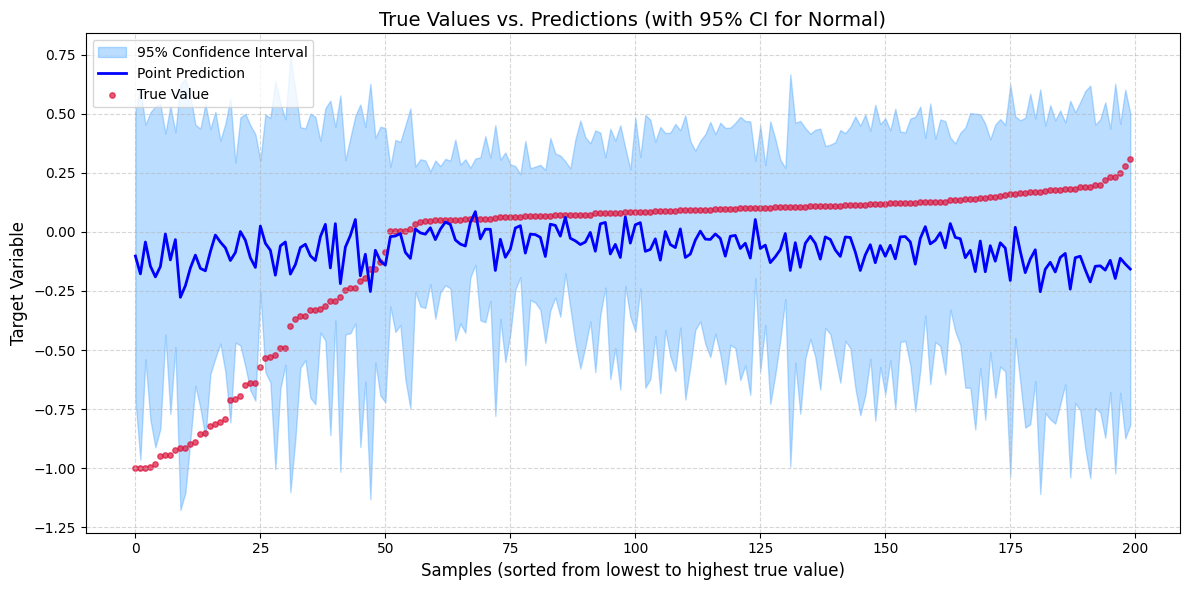

In [ ]:
# Visualize the predictions with confidence intervals on the holdout set
dist_name = best_dist_str

# Calculate 95% confidence intervals based on the predicted distribution and its parameters
if dist_name == "Normal":
    lower_bound = norm.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = norm.ppf(0.975, loc=holdout_point, scale=holdout_std)
elif dist_name == "Laplace":
    lower_bound = laplace.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = laplace.ppf(0.975, loc=holdout_point, scale=holdout_std)

# Sort the holdout predictions and true values for better visualization
sort_idx = np.argsort(y_val_holdout)
y_true_sorted = y_val_holdout[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

# Plot the true values, predictions and confidence intervals
plt.figure(figsize=(12, 6))
plt.fill_between(
    range(len(y_true_sorted)),
    lower_sorted,
    upper_sorted,
    color="dodgerblue",
    alpha=0.3,
    label="95% Confidence Interval",
)
plt.plot(
    range(len(y_true_sorted)),
    y_pred_sorted,
    color="blue",
    linewidth=2,
    label="Point Prediction",
)
plt.scatter(
    range(len(y_true_sorted)),
    y_true_sorted,
    color="crimson",
    s=15,
    alpha=0.7,
    label="True Value",
)
plt.title(f"True Values vs. Predictions (with 95% CI for {dist_name})", fontsize=14)
plt.xlabel("Samples (sorted from lowest to highest true value)", fontsize=12)
plt.ylabel("Target Variable", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

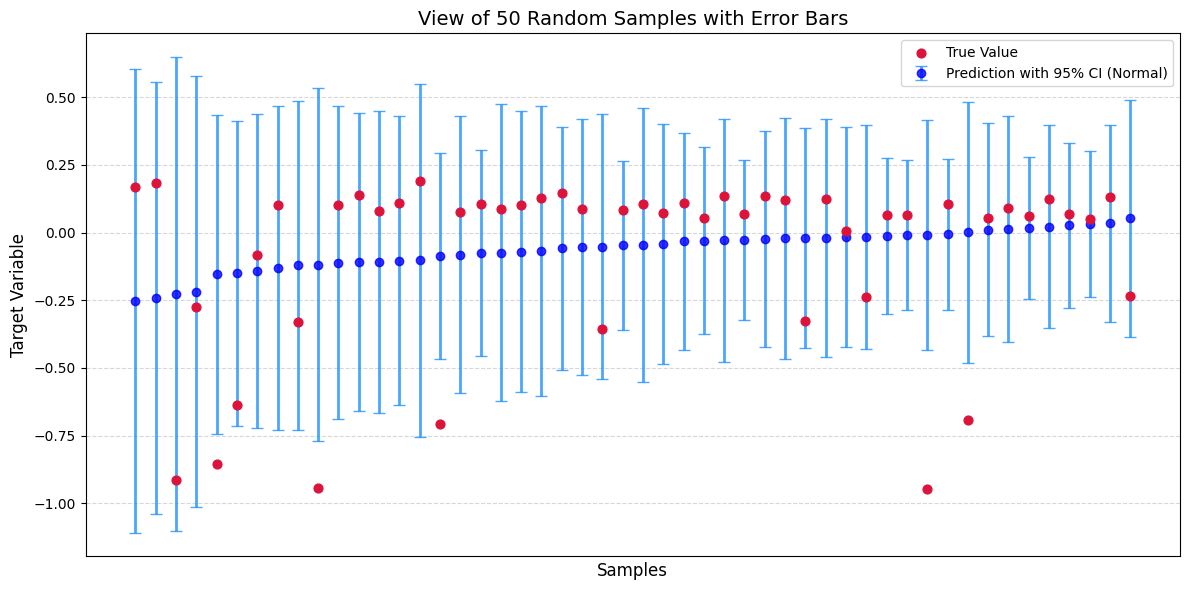

In [ ]:
# Plot a subset of samples with error bars to better visualize the confidence intervals
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

# Extract the true values, predictions and confidence intervals for the sampled indices
y_true_sample = y_val_holdout[sample_idx]
y_pred_sample = holdout_point[sample_idx]
lower_sample = lower_bound[sample_idx]
upper_sample = upper_bound[sample_idx]

# Sort the sampled predictions and true values for better visualization
sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
lower_sample = lower_sample[sort_idx]
upper_sample = upper_sample[sort_idx]

# Calculate the error bars for the plot
yerr_lower = y_pred_sample - lower_sample
yerr_upper = upper_sample - y_pred_sample

# Plot the sampled predictions with error bars representing the confidence intervals
plt.figure(figsize=(12, 6))
plt.errorbar(
    range(n_samples),
    y_pred_sample,
    yerr=[yerr_lower, yerr_upper],
    fmt="o",
    color="blue",
    ecolor="dodgerblue",
    elinewidth=2,
    capsize=4,
    alpha=0.8,
    label=f"Prediction with 95% CI ({dist_name})",
)
plt.scatter(
    range(n_samples), y_true_sample, color="crimson", s=40, zorder=3, label="True Value"
)
plt.title(f"View of {n_samples} Random Samples with Error Bars", fontsize=14)
plt.xlabel("Samples", fontsize=12)
plt.ylabel("Target Variable", fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### 10k

In [ ]:
# Parameter tuning settings
timeout_seconds = 60 * 60 * 1
no_improvement_trials = 100

# Split the 10k dataset to evaluate on holdout after tuning
X_tuning = train_10k_X.head(8000)
y_tuning = train_10k_y_reg.head(8000)
X_val_holdout = train_10k_X.tail(2000)
y_val_holdout = train_10k_y_reg.tail(2000)


# Define the objective function for Optuna to optimize
def objective_ngboost(trial):
    # Possible parameters to tune with ranges
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 8),  # Max tree depth
        "min_samples_split": trial.suggest_int(
            "base_min_samples_split", 15, 100
        ),  # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int(
            "base_min_samples_leaf", 15, 100
        ),  # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float(
            "base_min_weight_fraction_leaf", 0, 0.5
        ),  # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical(
            "base_max_features", ["sqrt", "log2", None]
        ),  # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float(
            "base_ccp_alpha", 1e-5, 0.1, log=True
        ),  # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int(
            "base_max_leaf_nodes", 3, 31
        ),  # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float(
            "base_min_impurity_decrease", 0, 1.0
        ),  # Min impurity decrease required for a split
        "random_state": 42,  # For reproducibility
    }

    base_learner = DecisionTreeRegressor(**base_params)

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 1000
        ),  # Number of boosting rounds,
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.005, 0.2, log=True
        ),  # Step size
        "minibatch_frac": trial.suggest_float(
            "minibatch_frac", 0.5, 1.0
        ),  # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float(
            "col_sample", 0.3, 0.8
        ),  # Fraction of features to consider for each base learner
        "random_state": 42,  # For reproducibility
        "verbose": False,  # No verbose output during training
    }

    # Suggest distribution as a string
    dist_choice = trial.suggest_categorical("Dist", ["Normal", "Laplace"])

    # Map the string to the imported class
    dist_mapping = {"Normal": Normal, "Laplace": Laplace}
    selected_dist = dist_mapping[dist_choice]

    full_pipeline = make_pipeline(
        numeric_preprocessor_reg,
        NGBRegressor(Dist=selected_dist, Base=base_learner, **params),
    )

    # TimeSeriesSplit to respect order of data 5 splits for 5-fold CV
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = []

    # 5-fold CV cycle
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values
        y_val = y_tuning.iloc[val_idx].values

        # Suppress warnings during fitting
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                full_pipeline.fit(
                    X_tr,
                    y_tr,
                )
        except np.linalg.LinAlgError:
            return 0.0

        # Calculate RMSE
        preds = full_pipeline.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        cv_scores.append(rmse)

    # Return mean RMSE across folds as the metric to minimize
    return np.mean(cv_scores)


# Custom callback to stop optimization if no improvement in best RMSE for a certain number of trials
def stop_optuna(study, trial):
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(
            f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization."
        )
        study.stop()


# Create Optuna study and optimize
study_ngboost = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_ngboost.optimize(
    objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna]
)

# Print best results and optimal parameters
print("\n" + "=" * 40)
print(f"BEST RMSE: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

# Calculate and print parameter importance
print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("=" * 40)

# Generate and show visualizations of optimization history,
# parameter importance and parallel coordinate plot
fig1 = plot_optimization_history(study_ngboost)
fig1.show()

fig2 = plot_param_importances(study_ngboost)
fig2.show()

fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()

# Save visualizations as HTML files
fig1.write_html(NGBOOST_TUNING_DIR_REG / "optuna_ngboost_rmse_10k_history.html")
fig2.write_html(NGBOOST_TUNING_DIR_REG / "optuna_ngboost_rmse_10k_importance.html")
fig3.write_html(NGBOOST_TUNING_DIR_REG / "optuna_ngboost_rmse_10k_parallel.html")

[I 2026-04-26 14:56:55,543] A new study created in memory with name: no-name-0306cac0-0209-4e09-83ab-9c206b111d3c
[I 2026-04-26 14:57:53,162] Trial 3 finished with value: 0.29790367520173117 and parameters: {'base_max_depth': 4, 'base_min_samples_split': 74, 'base_min_samples_leaf': 26, 'base_min_weight_fraction_leaf': 0.047106823491502026, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.00012278386422537847, 'base_max_leaf_nodes': 14, 'base_min_impurity_decrease': 0.7748632727850571, 'n_estimators': 222, 'learning_rate': 0.10977218542315906, 'minibatch_frac': 0.8850810425462461, 'col_sample': 0.3428234434984991, 'Dist': 'Normal'}. Best is trial 3 with value: 0.29790367520173117.
[I 2026-04-26 14:58:00,888] Trial 7 finished with value: 0.3212502798384557 and parameters: {'base_max_depth': 2, 'base_min_samples_split': 45, 'base_min_samples_leaf': 58, 'base_min_weight_fraction_leaf': 0.11072076148742765, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.09112224974885973, 'base_max_leaf_


[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 15:45:32,096] Trial 126 finished with value: 0.2995005340249176 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 45, 'base_min_samples_leaf': 44, 'base_min_weight_fraction_leaf': 0.015154655514940092, 'base_max_features': None, 'base_ccp_alpha': 0.0006590972652424751, 'base_max_leaf_nodes': 9, 'base_min_impurity_decrease': 0.4399542811881628, 'n_estimators': 754, 'learning_rate': 0.01740251642307955, 'minibatch_frac': 0.8094682038298125, 'col_sample': 0.7846087221713912, 'Dist': 'Normal'}. Best is trial 35 with value: 0.29695551557725314.
[I 2026-04-26 15:46:19,319] Trial 136 finished with value: 0.29744970291836 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 39, 'base_min_samples_leaf': 35, 'base_min_weight_fraction_leaf': 0.09167351628139857, 'base_max_features': 'log2', 'base_ccp_alpha': 1.3847384884708261e-05, 'base_max_leaf_nodes': 11, 'base_min_impurity_decrease': 0.4830331623572925, 'n_estimators': 765, 'learning_rate': 0.01642683275


[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 15:46:36,015] Trial 137 finished with value: 0.2977934684933173 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 56, 'base_min_samples_leaf': 35, 'base_min_weight_fraction_leaf': 0.0936394191449462, 'base_max_features': 'log2', 'base_ccp_alpha': 1.743614080068499e-05, 'base_max_leaf_nodes': 17, 'base_min_impurity_decrease': 0.36425381310868976, 'n_estimators': 775, 'learning_rate': 0.022969326735586423, 'minibatch_frac': 0.5421647958886651, 'col_sample': 0.7251195853423349, 'Dist': 'Normal'}. Best is trial 35 with value: 0.29695551557725314.


...


[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 15:46:46,324] Trial 139 finished with value: 0.30058258488074846 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 38, 'base_min_samples_leaf': 41, 'base_min_weight_fraction_leaf': 0.005023254371916931, 'base_max_features': 'log2', 'base_ccp_alpha': 0.08522579472360997, 'base_max_leaf_nodes': 17, 'base_min_impurity_decrease': 0.35960818859331056, 'n_estimators': 701, 'learning_rate': 0.015263857534112081, 'minibatch_frac': 0.5565215179963959, 'col_sample': 0.7293491885006906, 'Dist': 'Normal'}. Best is trial 35 with value: 0.29695551557725314.



[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-04-26 15:46:49,501] Trial 140 finished with value: 0.2968008923280196 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 38, 'base_min_samples_leaf': 41, 'base_min_weight_fraction_leaf': 0.0003213921303004477, 'base_max_features': 'log2', 'base_ccp_alpha': 1.8549133165544335e-05, 'base_max_leaf_nodes': 17, 'base_min_impurity_decrease': 0.38252906628451194, 'n_estimators': 714, 'learning_rate': 0.011486310063486665, 'minibatch_frac': 0.5442236810583654, 'col_sample': 0.7169685029737407, 'Dist': 'Normal'}. Best is trial 140 with value: 0.2968008923280196.
[I 2026-04-26 15:47:33,954] Trial 133 finished with value: 0.2990700398335759 and parameters: {'base_max_depth': 8, 'base_min_samples_split': 56, 'base_min_samples_leaf': 41, 'base_min_weight_fraction_leaf': 0.012794757633910745, 'base_max_features': None, 'base_ccp_alpha': 0.0006778926618524738, 'base_max_leaf_nodes': 11, 'base_min_impurity_decrease': 0.38728962065349193, 'n_estimators': 752, 'learning_rate': 0.016


BEST RMSE: 0.2968
BEST PARAMETERS:
best_params = {
    "base_max_depth": 8,
    "base_min_samples_split": 38,
    "base_min_samples_leaf": 41,
    "base_min_weight_fraction_leaf": 0.0003213921303004477,
    "base_max_features": "log2",
    "base_ccp_alpha": 1.8549133165544335e-05,
    "base_max_leaf_nodes": 17,
    "base_min_impurity_decrease": 0.38252906628451194,
    "n_estimators": 714,
    "learning_rate": 0.011486310063486665,
    "minibatch_frac": 0.5442236810583654,
    "col_sample": 0.7169685029737407,
    "Dist": "Normal",
}

--- PARAMETER IMPORTANCE ---
  Dist                : 0.9907
  learning_rate       : 0.0016
  col_sample          : 0.0015
  base_min_impurity_decrease: 0.0011
  base_max_leaf_nodes : 0.0010
  base_max_features   : 0.0010
  minibatch_frac      : 0.0009
  base_min_samples_split: 0.0008
  n_estimators        : 0.0004
  base_min_weight_fraction_leaf: 0.0004
  base_min_samples_leaf: 0.0003
  base_ccp_alpha      : 0.0002
  base_max_depth      : 0.0001


In [ ]:
# Check overfit on holdout set with best parameters from tuning
best_params = study_ngboost.best_params.copy()

# Separate parametersfor base learner and extraxt the distribution choice
best_dist_str = best_params.pop("Dist")
dist_mapping = {"Normal": Normal, "Laplace": Laplace}
best_dist = dist_mapping[best_dist_str]

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42,
}

base_learner = DecisionTreeRegressor(**base_params)

# Apply scaling trick
best_params["n_estimators"] = int(best_params["n_estimators"] * 2)
best_params["learning_rate"] = best_params["learning_rate"] / 2
# Add fixed parameters to best_params and print them
best_params["random_state"] = 42
best_params["verbose"] = False
print(f"BEST DIST: {best_dist_str}")
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning = y_tuning.values
y_val_holdout = y_val_holdout.values

final_pipeline = make_pipeline(
    numeric_preprocessor_reg, NGBRegressor(Dist=best_dist, Base=base_learner, **best_params)
)

# Fit on the entire tuning set
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning)

# Evaluate on holdout set
X_val_transformed = final_pipeline[:-1].transform(X_val_holdout)
holdout_dist = final_pipeline.named_steps["ngbregressor"].pred_dist(X_val_transformed)
holdout_point = holdout_dist.loc
holdout_std = holdout_dist.scale
holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout, holdout_point))

# Print comparison of Optuna CV RMSE and holdout test RMSE
print("\n" + "=" * 40)
print(f"Optuna Val RMSE:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("=" * 40)

BEST DIST: Normal
BASE PARAMS: {'criterion': 'friedman_mse', 'max_depth': 8, 'min_samples_split': 38, 'min_samples_leaf': 41, 'min_weight_fraction_leaf': 0.0003213921303004477, 'max_features': 'log2', 'ccp_alpha': 1.8549133165544335e-05, 'max_leaf_nodes': 17, 'min_impurity_decrease': 0.38252906628451194, 'random_state': 42}
BEST PARAMS: {'n_estimators': 1428, 'learning_rate': 0.005743155031743333, 'minibatch_frac': 0.5442236810583654, 'col_sample': 0.7169685029737407, 'random_state': 42, 'verbose': False}

Optuna Val RMSE:   0.2968
Holdout Test RMSE: 0.3117


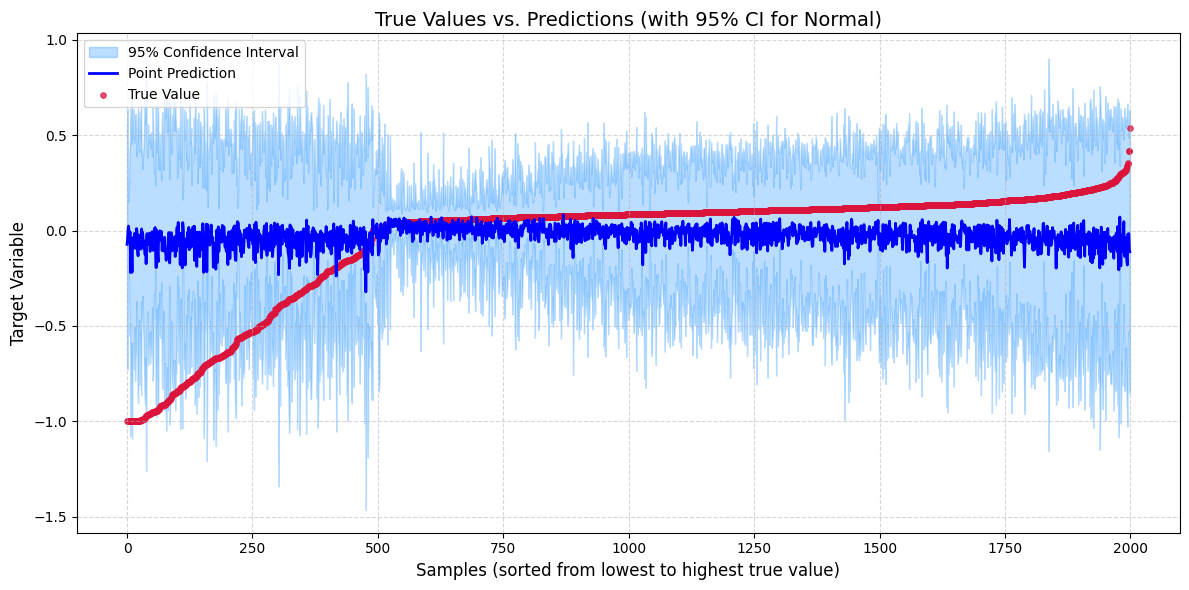

In [ ]:
# Visualize the predictions with confidence intervals on the holdout set
dist_name = best_dist_str

# Calculate 95% confidence intervals based on the predicted distribution and its parameters
if dist_name == "Normal":
    lower_bound = norm.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = norm.ppf(0.975, loc=holdout_point, scale=holdout_std)
elif dist_name == "Laplace":
    lower_bound = laplace.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = laplace.ppf(0.975, loc=holdout_point, scale=holdout_std)

# Sort the holdout predictions and true values for better visualization
sort_idx = np.argsort(y_val_holdout)
y_true_sorted = y_val_holdout[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

# Plot the true values, predictions and confidence intervals
plt.figure(figsize=(12, 6))
plt.fill_between(
    range(len(y_true_sorted)),
    lower_sorted,
    upper_sorted,
    color="dodgerblue",
    alpha=0.3,
    label="95% Confidence Interval",
)
plt.plot(
    range(len(y_true_sorted)),
    y_pred_sorted,
    color="blue",
    linewidth=2,
    label="Point Prediction",
)
plt.scatter(
    range(len(y_true_sorted)),
    y_true_sorted,
    color="crimson",
    s=15,
    alpha=0.7,
    label="True Value",
)
plt.title(f"True Values vs. Predictions (with 95% CI for {dist_name})", fontsize=14)
plt.xlabel("Samples (sorted from lowest to highest true value)", fontsize=12)
plt.ylabel("Target Variable", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

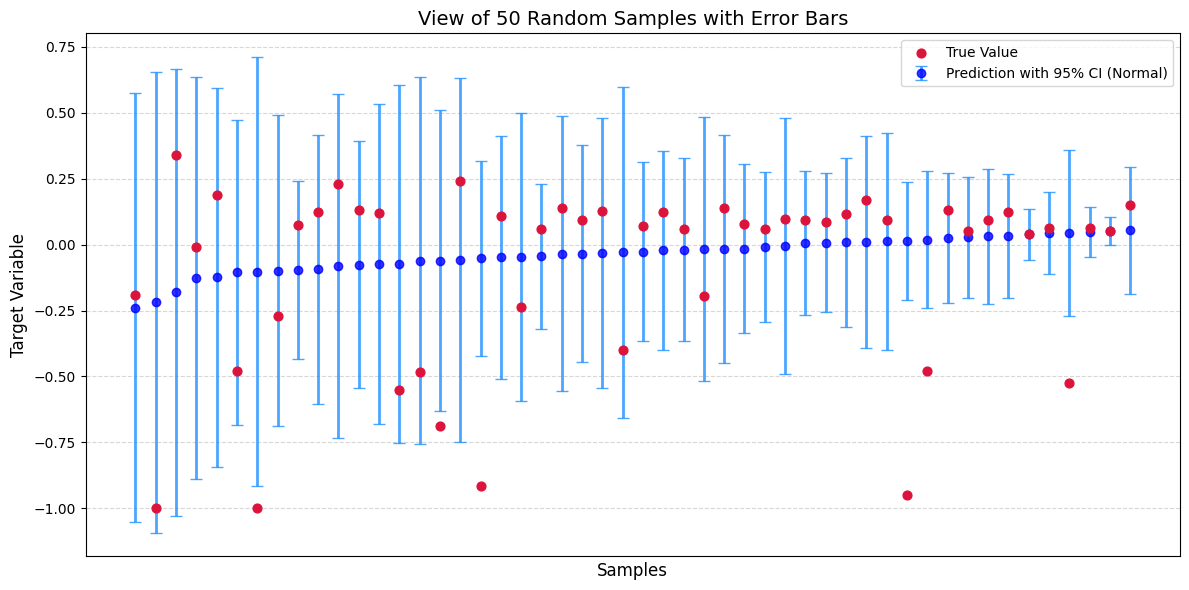

In [ ]:
# Plot a subset of samples with error bars to better visualize the confidence intervals
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

# Extract the true values, predictions and confidence intervals for the sampled indices
y_true_sample = y_val_holdout[sample_idx]
y_pred_sample = holdout_point[sample_idx]
lower_sample = lower_bound[sample_idx]
upper_sample = upper_bound[sample_idx]

# Sort the sampled predictions and true values for better visualization
sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
lower_sample = lower_sample[sort_idx]
upper_sample = upper_sample[sort_idx]

# Calculate the error bars for the plot
yerr_lower = y_pred_sample - lower_sample
yerr_upper = upper_sample - y_pred_sample

# Plot the sampled predictions with error bars representing the confidence intervals
plt.figure(figsize=(12, 6))
plt.errorbar(
    range(n_samples),
    y_pred_sample,
    yerr=[yerr_lower, yerr_upper],
    fmt="o",
    color="blue",
    ecolor="dodgerblue",
    elinewidth=2,
    capsize=4,
    alpha=0.8,
    label=f"Prediction with 95% CI ({dist_name})",
)
plt.scatter(
    range(n_samples), y_true_sample, color="crimson", s=40, zorder=3, label="True Value"
)
plt.title(f"View of {n_samples} Random Samples with Error Bars", fontsize=14)
plt.xlabel("Samples", fontsize=12)
plt.ylabel("Target Variable", fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### 100k

In [ ]:
# Parameter tuning settings
timeout_seconds = 60 * 60 * 3
no_improvement_trials = 100

# Split the 100k dataset to evaluate on holdout after tuning
X_tuning = train_100k_X.head(80000)
y_tuning = train_100k_y_reg.head(80000)
X_val_holdout = train_100k_X.tail(20000)
y_val_holdout = train_100k_y_reg.tail(20000)


# Define the objective function for Optuna to optimize
def objective_ngboost(trial):
    # Possible parameters to tune with ranges
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 20),  # Max tree depth
        "min_samples_split": trial.suggest_int(
            "base_min_samples_split", 10, 500
        ),  # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int(
            "base_min_samples_leaf", 10, 500
        ),  # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float(
            "base_min_weight_fraction_leaf", 0, 0.5
        ),  # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical(
            "base_max_features", ["sqrt", "log2", None]
        ),  # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float(
            "base_ccp_alpha", 1e-5, 0.1, log=True
        ),  # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int(
            "base_max_leaf_nodes", 5, 512
        ),  # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float(
            "base_min_impurity_decrease", 0, 1.0
        ),  # Min impurity decrease required for a split
        "random_state": 42,  # For reproducibility
    }

    base_learner = DecisionTreeRegressor(**base_params)

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 1000
        ),  # Number of boosting rounds,
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.005, 0.2, log=True
        ),  # Step size
        "minibatch_frac": trial.suggest_float(
            "minibatch_frac", 0.5, 1.0
        ),  # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float(
            "col_sample", 0.3, 1.0
        ),  # Fraction of features to consider for each base learner
        "random_state": 42,  # For reproducibility
        "verbose": False,  # No verbose output during training
    }

    # Suggest distribution as a string
    dist_choice = trial.suggest_categorical("Dist", ["Normal", "Laplace"])

    # Map the string to the imported class
    dist_mapping = {"Normal": Normal, "Laplace": Laplace}
    selected_dist = dist_mapping[dist_choice]

    full_pipeline = make_pipeline(
        numeric_preprocessor_reg,
        NGBRegressor(Dist=selected_dist, Base=base_learner, **params),
    )

    # TimeSeriesSplit to respect order of data 5 splits for 5-fold CV
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = []

    # 5-fold CV cycle
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values
        y_val = y_tuning.iloc[val_idx].values

        # Suppress warnings during fitting
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                full_pipeline.fit(
                    X_tr,
                    y_tr,
                )
        except np.linalg.LinAlgError:
            return 0.0

        # Calculate RMSE
        preds = full_pipeline.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        cv_scores.append(rmse)

    # Return mean RMSE across folds as the metric to minimize
    return np.mean(cv_scores)


# Custom callback to stop optimization if no improvement in best RMSE for a certain number of trials
def stop_optuna(study, trial):
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(
            f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization."
        )
        study.stop()


# Create Optuna study and optimize
study_ngboost = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_ngboost.optimize(
    objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna]
)

# Print best results and optimal parameters
print("\n" + "=" * 40)
print(f"BEST RMSE: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

# Calculate and print parameter importance
print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("=" * 40)

# Generate and show visualizations of optimization history,
# parameter importance and parallel coordinate plot
fig1 = plot_optimization_history(study_ngboost)
fig1.show()

fig2 = plot_param_importances(study_ngboost)
fig2.show()

fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()

# Save visualizations as HTML files
fig1.write_html(NGBOOST_TUNING_DIR_REG / "optuna_ngboost_rmse_100k_history.html")
fig2.write_html(NGBOOST_TUNING_DIR_REG / "optuna_ngboost_rmse_100k_importance.html")
fig3.write_html(NGBOOST_TUNING_DIR_REG / "optuna_ngboost_rmse_100k_parallel.html")

[I 2026-04-26 10:26:51,234] A new study created in memory with name: no-name-aa90b29e-a8e8-4516-bc18-57e76023b0fe
[I 2026-04-26 10:27:51,670] Trial 0 finished with value: 0.3085389717911731 and parameters: {'base_max_depth': 9, 'base_min_samples_split': 387, 'base_min_samples_leaf': 417, 'base_min_weight_fraction_leaf': 0.29480465210945106, 'base_max_features': 'log2', 'base_ccp_alpha': 0.07196803783402328, 'base_max_leaf_nodes': 389, 'base_min_impurity_decrease': 0.5906990917030795, 'n_estimators': 170, 'learning_rate': 0.14506884110770907, 'minibatch_frac': 0.9204469591020764, 'col_sample': 0.5985894741757924, 'Dist': 'Normal'}. Best is trial 0 with value: 0.3085389717911731.
[I 2026-04-26 10:28:04,936] Trial 2 finished with value: 0.3308522328859796 and parameters: {'base_max_depth': 5, 'base_min_samples_split': 66, 'base_min_samples_leaf': 40, 'base_min_weight_fraction_leaf': 0.3082518212556026, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.0010474915901119639, 'base_max_leaf_no


BEST RMSE: 0.2996
BEST PARAMETERS:
best_params = {
    "base_max_depth": 17,
    "base_min_samples_split": 35,
    "base_min_samples_leaf": 371,
    "base_min_weight_fraction_leaf": 0.003373989905557241,
    "base_max_features": "sqrt",
    "base_ccp_alpha": 2.1975874211460698e-05,
    "base_max_leaf_nodes": 30,
    "base_min_impurity_decrease": 0.035785241864927805,
    "n_estimators": 354,
    "learning_rate": 0.031005975042584923,
    "minibatch_frac": 0.5337656312465495,
    "col_sample": 0.7957079748440611,
    "Dist": "Normal",
}

--- PARAMETER IMPORTANCE ---
  Dist                : 0.9735
  learning_rate       : 0.0089
  base_max_depth      : 0.0087
  n_estimators        : 0.0024
  base_min_samples_split: 0.0012
  base_min_weight_fraction_leaf: 0.0011
  base_max_features   : 0.0009
  col_sample          : 0.0009
  minibatch_frac      : 0.0007
  base_min_samples_leaf: 0.0005
  base_ccp_alpha      : 0.0004
  base_min_impurity_decrease: 0.0004
  base_max_leaf_nodes : 0.0004


In [ ]:
# Check overfit on holdout set with best parameters from tuning
best_params = study_ngboost.best_params.copy()

# Separate parametersfor base learner and extraxt the distribution choice
best_dist_str = best_params.pop("Dist")
dist_mapping = {"Normal": Normal, "Laplace": Laplace}
best_dist = dist_mapping[best_dist_str]

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42,
}

base_learner = DecisionTreeRegressor(**base_params)

# Apply scaling trick
best_params["n_estimators"] = int(best_params["n_estimators"] * 10)
best_params["learning_rate"] = best_params["learning_rate"] / 10
# Add fixed parameters to best_params and print them
best_params["random_state"] = 42
best_params["verbose"] = False
print(f"BEST DIST: {best_dist_str}")
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning = y_tuning.values
y_val_holdout = y_val_holdout.values

final_pipeline = make_pipeline(
    numeric_preprocessor_reg, NGBRegressor(Dist=best_dist, Base=base_learner, **best_params)
)

# Fit on the entire tuning set
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning)

# Evaluate on holdout set
X_val_transformed = final_pipeline[:-1].transform(X_val_holdout)
holdout_dist = final_pipeline.named_steps["ngbregressor"].pred_dist(X_val_transformed)
holdout_point = holdout_dist.loc
holdout_std = holdout_dist.scale
holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout, holdout_point))

# Print comparison of Optuna CV RMSE and holdout test RMSE
print("\n" + "=" * 40)
print(f"Optuna Val RMSE:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("=" * 40)

BEST DIST: Normal
BASE PARAMS: {'criterion': 'friedman_mse', 'max_depth': 17, 'min_samples_split': 35, 'min_samples_leaf': 371, 'min_weight_fraction_leaf': 0.003373989905557241, 'max_features': 'sqrt', 'ccp_alpha': 2.1975874211460698e-05, 'max_leaf_nodes': 30, 'min_impurity_decrease': 0.035785241864927805, 'random_state': 42}
BEST PARAMS: {'n_estimators': 3540, 'learning_rate': 0.0031005975042584922, 'minibatch_frac': 0.5337656312465495, 'col_sample': 0.7957079748440611, 'random_state': 42, 'verbose': False}

Optuna Val RMSE:   0.2996
Holdout Test RMSE: 0.2986


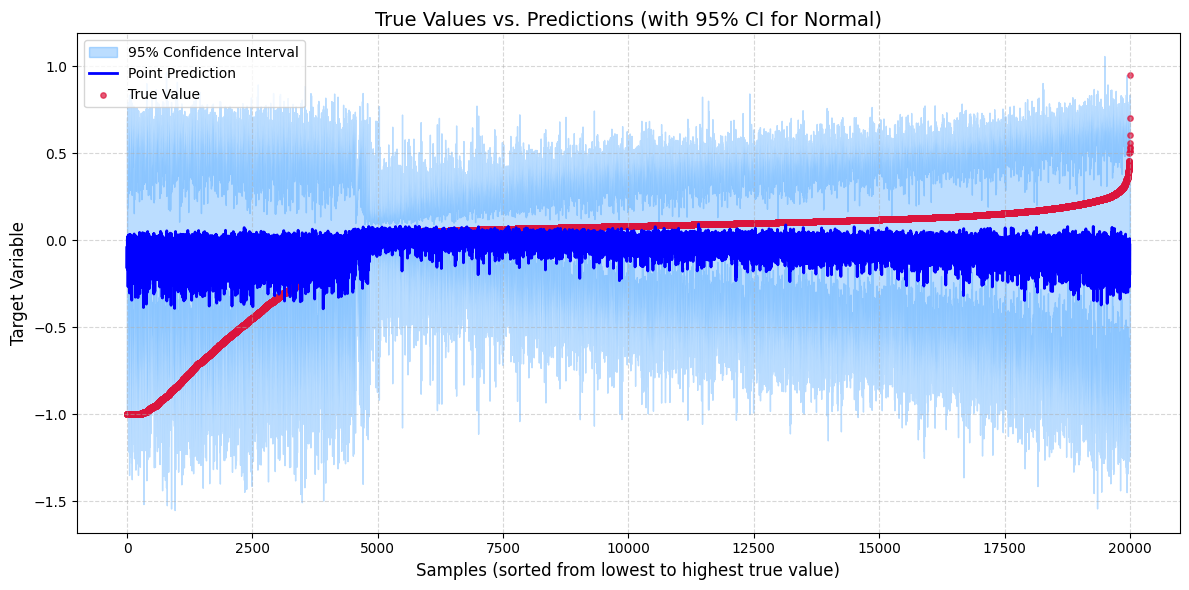

In [ ]:
# Visualize the predictions with confidence intervals on the holdout set
dist_name = best_dist_str

# Calculate 95% confidence intervals based on the predicted distribution and its parameters
if dist_name == "Normal":
    lower_bound = norm.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = norm.ppf(0.975, loc=holdout_point, scale=holdout_std)
elif dist_name == "Laplace":
    lower_bound = laplace.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = laplace.ppf(0.975, loc=holdout_point, scale=holdout_std)

# Sort the holdout predictions and true values for better visualization
sort_idx = np.argsort(y_val_holdout)
y_true_sorted = y_val_holdout[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

# Plot the true values, predictions and confidence intervals
plt.figure(figsize=(12, 6))
plt.fill_between(
    range(len(y_true_sorted)),
    lower_sorted,
    upper_sorted,
    color="dodgerblue",
    alpha=0.3,
    label="95% Confidence Interval",
)
plt.plot(
    range(len(y_true_sorted)),
    y_pred_sorted,
    color="blue",
    linewidth=2,
    label="Point Prediction",
)
plt.scatter(
    range(len(y_true_sorted)),
    y_true_sorted,
    color="crimson",
    s=15,
    alpha=0.7,
    label="True Value",
)
plt.title(f"True Values vs. Predictions (with 95% CI for {dist_name})", fontsize=14)
plt.xlabel("Samples (sorted from lowest to highest true value)", fontsize=12)
plt.ylabel("Target Variable", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

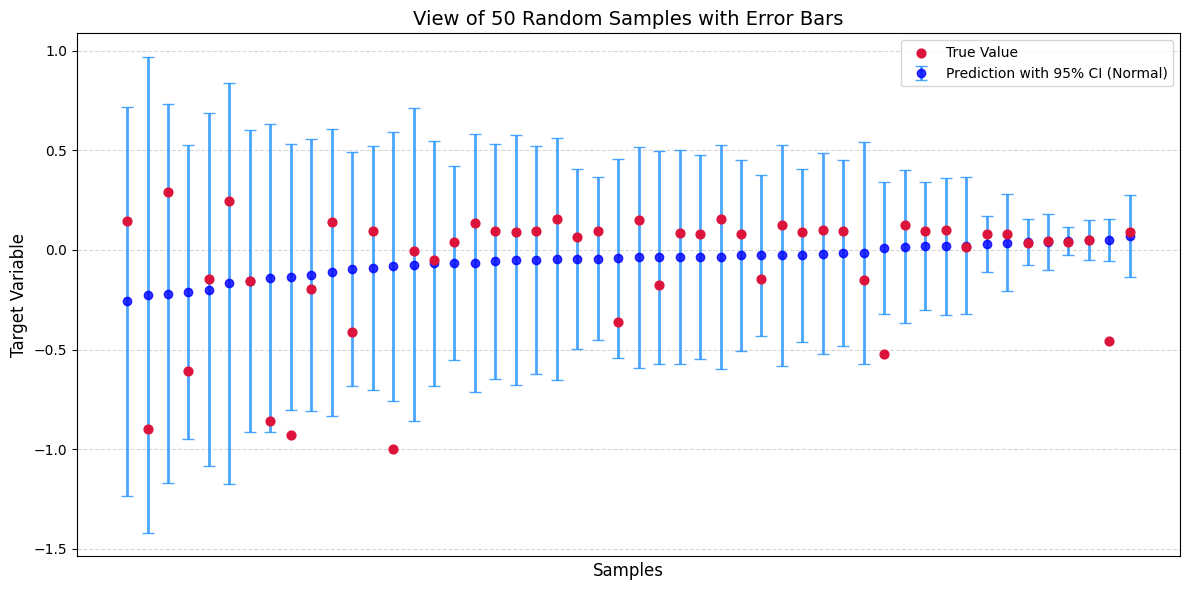

In [ ]:
# Plot a subset of samples with error bars to better visualize the confidence intervals
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

# Extract the true values, predictions and confidence intervals for the sampled indices
y_true_sample = y_val_holdout[sample_idx]
y_pred_sample = holdout_point[sample_idx]
lower_sample = lower_bound[sample_idx]
upper_sample = upper_bound[sample_idx]

# Sort the sampled predictions and true values for better visualization
sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
lower_sample = lower_sample[sort_idx]
upper_sample = upper_sample[sort_idx]

# Calculate the error bars for the plot
yerr_lower = y_pred_sample - lower_sample
yerr_upper = upper_sample - y_pred_sample

# Plot the sampled predictions with error bars representing the confidence intervals
plt.figure(figsize=(12, 6))
plt.errorbar(
    range(n_samples),
    y_pred_sample,
    yerr=[yerr_lower, yerr_upper],
    fmt="o",
    color="blue",
    ecolor="dodgerblue",
    elinewidth=2,
    capsize=4,
    alpha=0.8,
    label=f"Prediction with 95% CI ({dist_name})",
)
plt.scatter(
    range(n_samples), y_true_sample, color="crimson", s=40, zorder=3, label="True Value"
)
plt.title(f"View of {n_samples} Random Samples with Error Bars", fontsize=14)
plt.xlabel("Samples", fontsize=12)
plt.ylabel("Target Variable", fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## CRPS

### 1k

In [ ]:
# Parameter tuning settings
timeout_seconds = 60 * 60 * 0.5
no_improvement_trials = 100

# Split the 1k dataset to evaluate on holdout after tuning
# Had problem with overfitting and extreme bad results on last 200 rows so switched the order
X_tuning = train_1k_X.tail(800)
y_tuning = train_1k_y_reg.tail(800)
X_val_holdout = train_1k_X.head(200)
y_val_holdout = train_1k_y_reg.head(200)


# Define the objective function for Optuna to optimize
def objective_ngboost(trial):
    # Possible parameters to tune with ranges
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 8),  # Max tree depth
        "min_samples_split": trial.suggest_int(
            "base_min_samples_split", 15, 100
        ),  # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int(
            "base_min_samples_leaf", 15, 100
        ),  # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float(
            "base_min_weight_fraction_leaf", 0, 0.5
        ),  # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical(
            "base_max_features", ["sqrt", "log2", None]
        ),  # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float(
            "base_ccp_alpha", 1e-5, 0.1, log=True
        ),  # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int(
            "base_max_leaf_nodes", 3, 31
        ),  # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float(
            "base_min_impurity_decrease", 0, 1.0
        ),  # Min impurity decrease required for a split
        "random_state": 42,  # For reproducibility
    }

    base_learner = DecisionTreeRegressor(**base_params)

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 1000
        ),  # Number of boosting rounds,
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.005, 0.2, log=True
        ),  # Step size
        "minibatch_frac": trial.suggest_float(
            "minibatch_frac", 0.5, 1.0
        ),  # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float(
            "col_sample", 0.3, 0.8
        ),  # Fraction of features to consider for each base learner
        "random_state": 42,  # For reproducibility
        "verbose": False,  # No verbose output during training
    }

    # Suggest distribution as a string
    dist_choice = trial.suggest_categorical("Dist", ["Normal", "Laplace"])

    # Map the string to the imported class
    dist_mapping = {"Normal": Normal, "Laplace": Laplace}
    selected_dist = dist_mapping[dist_choice]

    full_pipeline = make_pipeline(
        numeric_preprocessor_reg,
        NGBRegressor(Dist=selected_dist, Base=base_learner, Score=CRPScore, **params),
    )

    # TimeSeriesSplit to respect order of data 3 splits for 3-fold CV
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []

    # 3-fold CV cycle
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values
        y_val = y_tuning.iloc[val_idx].values

        # Suppress warnings during fitting
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                full_pipeline.fit(
                    X_tr,
                    y_tr,
                )
                # Calculate CRPS
                mean_fold_crps = full_pipeline.score(X_val, y_val) 
        except np.linalg.LinAlgError:
            return 0.0

        cv_scores.append(mean_fold_crps)

    # Return mean CRPS across folds as the metric to minimize
    return np.mean(cv_scores)


# Custom callback to stop optimization if no improvement in best CRPS for a certain number of trials
def stop_optuna(study, trial):
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(
            f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization."
        )
        study.stop()


# Create Optuna study and optimize
study_ngboost = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_ngboost.optimize(
    objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna]
)

# Print best results and optimal parameters
print("\n" + "=" * 40)
print(f"BEST CRPS: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

# Calculate and print parameter importance
print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("=" * 40)

# Generate and show visualizations of optimization history,
# parameter importance and parallel coordinate plot
fig1 = plot_optimization_history(study_ngboost)
fig1.show()

fig2 = plot_param_importances(study_ngboost)
fig2.show()

fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()

# Save visualizations as HTML files
fig1.write_html(NGBOOST_TUNING_DIR_REG / "optuna_ngboost_crps_1k_history.html")
fig2.write_html(NGBOOST_TUNING_DIR_REG / "optuna_ngboost_crps_1k_importance.html")
fig3.write_html(NGBOOST_TUNING_DIR_REG / "optuna_ngboost_crps_1k_parallel.html")

[I 2026-05-03 21:48:14,552] A new study created in memory with name: no-name-e14c0160-1662-4c64-a503-cfdb96fb31c2
[I 2026-05-03 21:48:53,593] Trial 7 finished with value: 0.18632154487551322 and parameters: {'base_max_depth': 2, 'base_min_samples_split': 57, 'base_min_samples_leaf': 25, 'base_min_weight_fraction_leaf': 0.438556507313945, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.0005240607826161324, 'base_max_leaf_nodes': 22, 'base_min_impurity_decrease': 0.9601436592652335, 'n_estimators': 276, 'learning_rate': 0.014575003978346756, 'minibatch_frac': 0.5096698800303288, 'col_sample': 0.5218168357554943, 'Dist': 'Laplace'}. Best is trial 7 with value: 0.18632154487551322.
[I 2026-05-03 21:48:55,232] Trial 6 finished with value: 0.18698436669430676 and parameters: {'base_max_depth': 6, 'base_min_samples_split': 29, 'base_min_samples_leaf': 27, 'base_min_weight_fraction_leaf': 0.102242905743058, 'base_max_features': 'log2', 'base_ccp_alpha': 0.003531956113632176, 'base_max_leaf_no


[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-05-03 22:14:55,754] Trial 333 finished with value: 0.17737525809728005 and parameters: {'base_max_depth': 5, 'base_min_samples_split': 49, 'base_min_samples_leaf': 27, 'base_min_weight_fraction_leaf': 0.02687813670876875, 'base_max_features': None, 'base_ccp_alpha': 0.0019977433266103926, 'base_max_leaf_nodes': 11, 'base_min_impurity_decrease': 0.6318867079890945, 'n_estimators': 237, 'learning_rate': 0.007177194879279911, 'minibatch_frac': 0.7608958501770409, 'col_sample': 0.3673262646049481, 'Dist': 'Normal'}. Best is trial 231 with value: 0.17718660414471707.



[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-05-03 22:14:57,713] Trial 332 finished with value: 0.17734180911585753 and parameters: {'base_max_depth': 5, 'base_min_samples_split': 50, 'base_min_samples_leaf': 27, 'base_min_weight_fraction_leaf': 0.0251678605625233, 'base_max_features': None, 'base_ccp_alpha': 0.00036419713142555113, 'base_max_leaf_nodes': 11, 'base_min_impurity_decrease': 0.9581314877882502, 'n_estimators': 272, 'learning_rate': 0.005024677066963928, 'minibatch_frac': 0.7723063799872211, 'col_sample': 0.3465210366833762, 'Dist': 'Normal'}. Best is trial 231 with value: 0.17718660414471707.
[I 2026-05-03 22:14:57,780] Trial 335 finished with value: 0.17797465892488917 and parameters: {'base_max_depth': 5, 'base_min_samples_split': 61, 'base_min_samples_leaf': 31, 'base_min_weight_fraction_leaf': 0.02475266312096911, 'base_max_features': None, 'base_ccp_alpha': 0.004281168965424217, 'base_max_leaf_nodes': 14, 'base_min_impurity_decrease': 0.07570952666040942, 'n_estimators': 204, 'learning_rate': 0.00724791

...


[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-05-03 22:15:01,805] Trial 336 finished with value: 0.17782105677436758 and parameters: {'base_max_depth': 5, 'base_min_samples_split': 62, 'base_min_samples_leaf': 31, 'base_min_weight_fraction_leaf': 0.06058970435019012, 'base_max_features': None, 'base_ccp_alpha': 0.000362187028865437, 'base_max_leaf_nodes': 13, 'base_min_impurity_decrease': 0.7155731449693846, 'n_estimators': 273, 'learning_rate': 0.007288929038744993, 'minibatch_frac': 0.7384029274564674, 'col_sample': 0.5455957362919257, 'Dist': 'Normal'}. Best is trial 231 with value: 0.17718660414471707.



[Early Stop] No improvement in 100 trials. Stopping optimization.


[I 2026-05-03 22:15:02,295] Trial 317 finished with value: 0.18179386561977084 and parameters: {'base_max_depth': 5, 'base_min_samples_split': 67, 'base_min_samples_leaf': 24, 'base_min_weight_fraction_leaf': 0.013731506212357936, 'base_max_features': None, 'base_ccp_alpha': 0.0025623813005486054, 'base_max_leaf_nodes': 9, 'base_min_impurity_decrease': 0.07930931827142412, 'n_estimators': 676, 'learning_rate': 0.005227107621406131, 'minibatch_frac': 0.8805056053245287, 'col_sample': 0.5424992873907841, 'Dist': 'Normal'}. Best is trial 231 with value: 0.17718660414471707.



BEST CRPS: 0.1772
BEST PARAMETERS:
best_params = {
    "base_max_depth": 5,
    "base_min_samples_split": 58,
    "base_min_samples_leaf": 29,
    "base_min_weight_fraction_leaf": 0.017281333237189084,
    "base_max_features": None,
    "base_ccp_alpha": 0.003052700344259774,
    "base_max_leaf_nodes": 16,
    "base_min_impurity_decrease": 0.05381132370811925,
    "n_estimators": 283,
    "learning_rate": 0.005033780214581703,
    "minibatch_frac": 0.7915298577355765,
    "col_sample": 0.36344911674618813,
    "Dist": "Normal",
}

--- PARAMETER IMPORTANCE ---
  learning_rate       : 0.2213
  base_min_samples_leaf: 0.2143
  base_min_weight_fraction_leaf: 0.1044
  Dist                : 0.1016
  base_min_samples_split: 0.0888
  base_min_impurity_decrease: 0.0785
  n_estimators        : 0.0451
  col_sample          : 0.0441
  base_max_leaf_nodes : 0.0305
  base_ccp_alpha      : 0.0213
  minibatch_frac      : 0.0206
  base_max_features   : 0.0198
  base_max_depth      : 0.0098


In [ ]:
# Check overfit on holdout set with best parameters from tuning
best_params = study_ngboost.best_params.copy()

# Separate parametersfor base learner and extraxt the distribution choice
best_dist_str = best_params.pop("Dist")
dist_mapping = {"Normal": Normal, "Laplace": Laplace}
best_dist = dist_mapping[best_dist_str]

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42,
}

base_learner = DecisionTreeRegressor(**base_params)

# Add fixed parameters to best_params and print them
best_params["random_state"] = 42
best_params["verbose"] = False
print(f"BEST DIST: {best_dist_str}")
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning = y_tuning.values
y_val_holdout = y_val_holdout.values

final_pipeline = make_pipeline(
    numeric_preprocessor_reg,
    NGBRegressor(Dist=best_dist, Score=CRPScore, Base=base_learner, **best_params),
)

# Fit on the entire tuning set
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning)

# Evaluate on holdout set
X_val_transformed = final_pipeline[:-1].transform(X_val_holdout)
holdout_dist = final_pipeline.named_steps["ngbregressor"].pred_dist(X_val_transformed)
holdout_point = holdout_dist.loc
holdout_std = holdout_dist.scale
holdout_crps = final_pipeline.score(X_val_holdout, y_val_holdout)
holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout, holdout_point))

# Print comparison of Optuna CV CRPS and holdout test CRPS
print("\n" + "=" * 40)
print(f"Optuna Val CRPS:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test CRPS: {holdout_crps:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("=" * 40)

BEST DIST: Normal
BASE PARAMS: {'criterion': 'friedman_mse', 'max_depth': 5, 'min_samples_split': 58, 'min_samples_leaf': 29, 'min_weight_fraction_leaf': 0.017281333237189084, 'max_features': None, 'ccp_alpha': 0.003052700344259774, 'max_leaf_nodes': 16, 'min_impurity_decrease': 0.05381132370811925, 'random_state': 42}
BEST PARAMS: {'n_estimators': 283, 'learning_rate': 0.005033780214581703, 'minibatch_frac': 0.7915298577355765, 'col_sample': 0.36344911674618813, 'random_state': 42, 'verbose': False}

Optuna Val CRPS:   0.1772
Holdout Test CRPS: 0.1326
Holdout Test RMSE: 0.2909


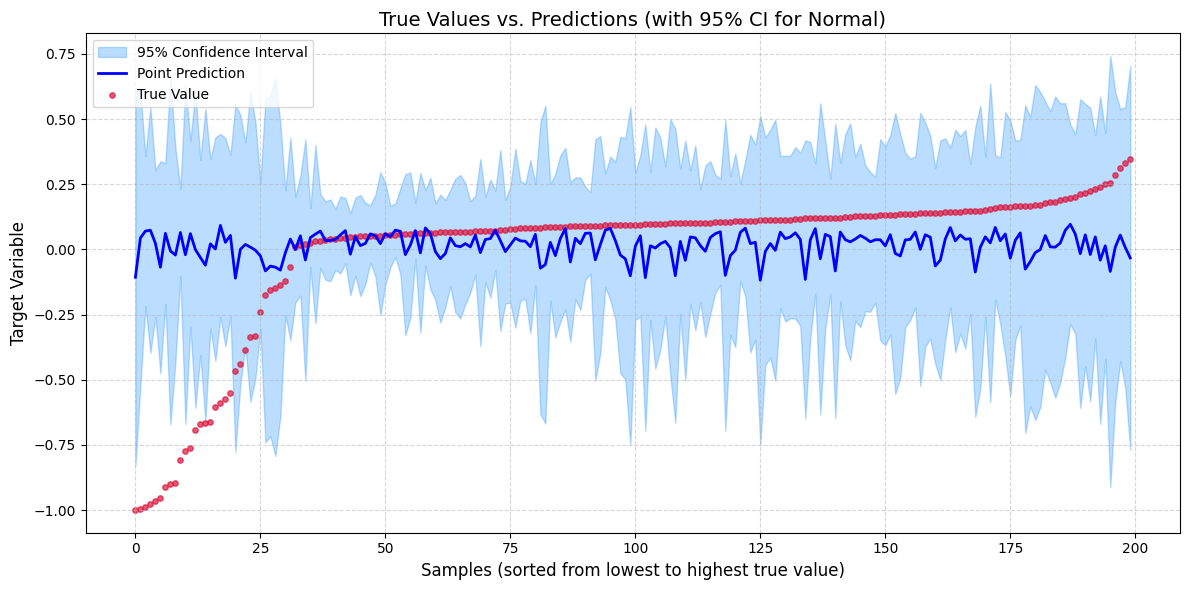

In [9]:
# Visualize the predictions with confidence intervals on the holdout set
dist_name = best_dist_str

# Calculate 95% confidence intervals based on the predicted distribution and its parameters
if dist_name == "Normal":
    lower_bound = norm.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = norm.ppf(0.975, loc=holdout_point, scale=holdout_std)
elif dist_name == "Laplace":
    lower_bound = laplace.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = laplace.ppf(0.975, loc=holdout_point, scale=holdout_std)

# Sort the holdout predictions and true values for better visualization
sort_idx = np.argsort(y_val_holdout)
y_true_sorted = y_val_holdout[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

# Plot the true values, predictions and confidence intervals
plt.figure(figsize=(12, 6))
plt.fill_between(
    range(len(y_true_sorted)),
    lower_sorted,
    upper_sorted,
    color="dodgerblue",
    alpha=0.3,
    label="95% Confidence Interval",
)
plt.plot(
    range(len(y_true_sorted)),
    y_pred_sorted,
    color="blue",
    linewidth=2,
    label="Point Prediction",
)
plt.scatter(
    range(len(y_true_sorted)),
    y_true_sorted,
    color="crimson",
    s=15,
    alpha=0.7,
    label="True Value",
)
plt.title(f"True Values vs. Predictions (with 95% CI for {dist_name})", fontsize=14)
plt.xlabel("Samples (sorted from lowest to highest true value)", fontsize=12)
plt.ylabel("Target Variable", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

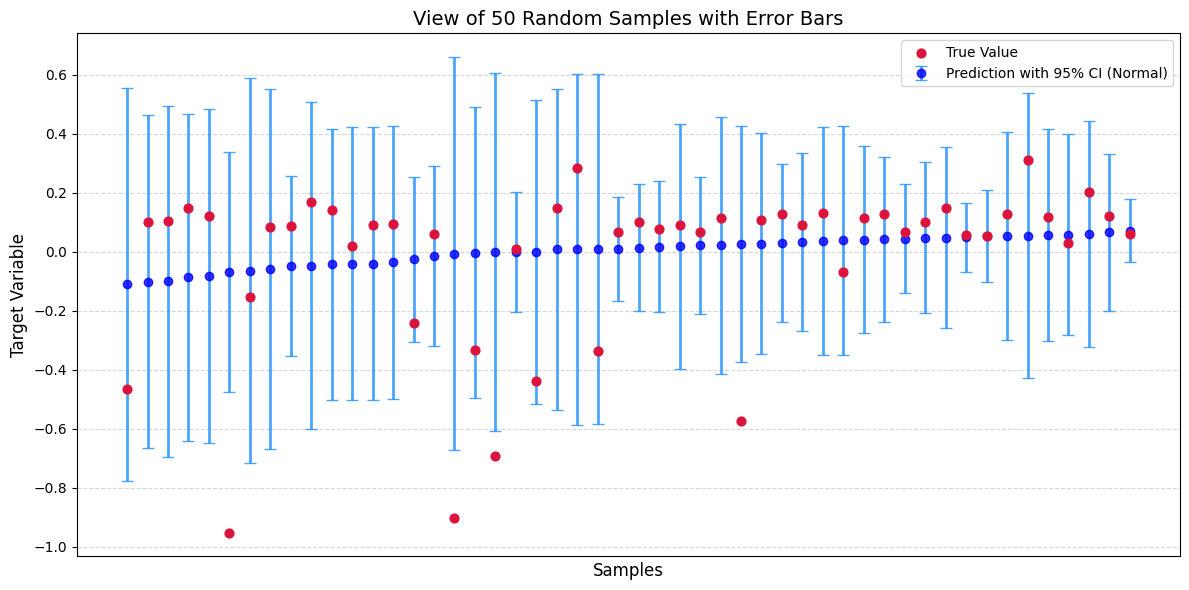

In [10]:
# Plot a subset of samples with error bars to better visualize the confidence intervals
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

# Extract the true values, predictions and confidence intervals for the sampled indices
y_true_sample = y_val_holdout[sample_idx]
y_pred_sample = holdout_point[sample_idx]
lower_sample = lower_bound[sample_idx]
upper_sample = upper_bound[sample_idx]

# Sort the sampled predictions and true values for better visualization
sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
lower_sample = lower_sample[sort_idx]
upper_sample = upper_sample[sort_idx]

# Calculate the error bars for the plot
yerr_lower = y_pred_sample - lower_sample
yerr_upper = upper_sample - y_pred_sample

# Plot the sampled predictions with error bars representing the confidence intervals
plt.figure(figsize=(12, 6))
plt.errorbar(
    range(n_samples),
    y_pred_sample,
    yerr=[yerr_lower, yerr_upper],
    fmt="o",
    color="blue",
    ecolor="dodgerblue",
    elinewidth=2,
    capsize=4,
    alpha=0.8,
    label=f"Prediction with 95% CI ({dist_name})",
)
plt.scatter(
    range(n_samples), y_true_sample, color="crimson", s=40, zorder=3, label="True Value"
)
plt.title(f"View of {n_samples} Random Samples with Error Bars", fontsize=14)
plt.xlabel("Samples", fontsize=12)
plt.ylabel("Target Variable", fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### 10k

In [ ]:
# Parameter tuning settings
timeout_seconds = 60 * 60 * 1
no_improvement_trials = 100

# Split the 10k dataset to evaluate on holdout after tuning
X_tuning = train_10k_X.head(8000)
y_tuning = train_10k_y_reg.head(8000)
X_val_holdout = train_10k_X.tail(2000)
y_val_holdout = train_10k_y_reg.tail(2000)


# Define the objective function for Optuna to optimize
def objective_ngboost(trial):
    # Possible parameters to tune with ranges
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 8),  # Max tree depth
        "min_samples_split": trial.suggest_int(
            "base_min_samples_split", 15, 100
        ),  # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int(
            "base_min_samples_leaf", 15, 100
        ),  # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float(
            "base_min_weight_fraction_leaf", 0, 0.5
        ),  # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical(
            "base_max_features", ["sqrt", "log2", None]
        ),  # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float(
            "base_ccp_alpha", 1e-5, 0.1, log=True
        ),  # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int(
            "base_max_leaf_nodes", 3, 31
        ),  # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float(
            "base_min_impurity_decrease", 0, 1.0
        ),  # Min impurity decrease required for a split
        "random_state": 42,  # For reproducibility
    }

    base_learner = DecisionTreeRegressor(**base_params)

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 1000
        ),  # Number of boosting rounds,
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.005, 0.2, log=True
        ),  # Step size
        "minibatch_frac": trial.suggest_float(
            "minibatch_frac", 0.5, 1.0
        ),  # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float(
            "col_sample", 0.3, 0.8
        ),  # Fraction of features to consider for each base learner
        "random_state": 42,  # For reproducibility
        "verbose": False,  # No verbose output during training
    }

    # Suggest distribution as a string
    dist_choice = trial.suggest_categorical("Dist", ["Normal", "Laplace"])

    # Map the string to the imported class
    dist_mapping = {"Normal": Normal, "Laplace": Laplace}
    selected_dist = dist_mapping[dist_choice]

    full_pipeline = make_pipeline(
        numeric_preprocessor_reg,
        NGBRegressor(Dist=selected_dist, Base=base_learner, Score=CRPScore, **params),
    )

    # TimeSeriesSplit to respect order of data 5 splits for 5-fold CV
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = []

    # 5-fold CV cycle
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values
        y_val = y_tuning.iloc[val_idx].values

        # Suppress warnings during fitting
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                full_pipeline.fit(
                    X_tr,
                    y_tr,
                )
                # Calculate CRPS
                mean_fold_crps = full_pipeline.score(X_val, y_val) 
        except np.linalg.LinAlgError:
            return 0.0

        cv_scores.append(mean_fold_crps)

    # Return mean CRPS across folds as the metric to minimize
    return np.mean(cv_scores)


# Custom callback to stop optimization if no improvement in best CRPS for a certain number of trials
def stop_optuna(study, trial):
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(
            f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization."
        )
        study.stop()


# Create Optuna study and optimize
study_ngboost = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_ngboost.optimize(
    objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna]
)

# Print best results and optimal parameters
print("\n" + "=" * 40)
print(f"BEST CRPS: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

# Calculate and print parameter importance
print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("=" * 40)

# Generate and show visualizations of optimization history,
# parameter importance and parallel coordinate plot
fig1 = plot_optimization_history(study_ngboost)
fig1.show()

fig2 = plot_param_importances(study_ngboost)
fig2.show()

fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()

# Save visualizations as HTML files
fig1.write_html(NGBOOST_TUNING_DIR_REG / "optuna_ngboost_crps_10k_history.html")
fig2.write_html(NGBOOST_TUNING_DIR_REG / "optuna_ngboost_crps_10k_importance.html")
fig3.write_html(NGBOOST_TUNING_DIR_REG / "optuna_ngboost_crps_10k_parallel.html")

[I 2026-05-03 22:15:10,359] A new study created in memory with name: no-name-6267b6b1-be87-4957-8e04-1bd072779dae
[I 2026-05-03 22:16:22,236] Trial 5 finished with value: 0.14009376142868246 and parameters: {'base_max_depth': 3, 'base_min_samples_split': 22, 'base_min_samples_leaf': 68, 'base_min_weight_fraction_leaf': 0.1502969844401748, 'base_max_features': 'log2', 'base_ccp_alpha': 0.00030093483920016323, 'base_max_leaf_nodes': 3, 'base_min_impurity_decrease': 0.5681180898853896, 'n_estimators': 246, 'learning_rate': 0.03796512030702582, 'minibatch_frac': 0.8309487147782963, 'col_sample': 0.5386895386370156, 'Dist': 'Laplace'}. Best is trial 5 with value: 0.14009376142868246.
[I 2026-05-03 22:16:27,907] Trial 1 finished with value: 0.13982719222051093 and parameters: {'base_max_depth': 6, 'base_min_samples_split': 22, 'base_min_samples_leaf': 31, 'base_min_weight_fraction_leaf': 0.28058810218359803, 'base_max_features': None, 'base_ccp_alpha': 0.0459716007199369, 'base_max_leaf_node


BEST CRPS: 0.1324
BEST PARAMETERS:
best_params = {
    "base_max_depth": 8,
    "base_min_samples_split": 47,
    "base_min_samples_leaf": 71,
    "base_min_weight_fraction_leaf": 0.07209438687070353,
    "base_max_features": None,
    "base_ccp_alpha": 0.0028141681107999054,
    "base_max_leaf_nodes": 28,
    "base_min_impurity_decrease": 0.5465685212315107,
    "n_estimators": 373,
    "learning_rate": 0.012249653079315102,
    "minibatch_frac": 0.7997422089482649,
    "col_sample": 0.5640858380003613,
    "Dist": "Normal",
}

--- PARAMETER IMPORTANCE ---
  Dist                : 0.9686
  base_max_features   : 0.0183
  base_min_weight_fraction_leaf: 0.0071
  learning_rate       : 0.0014
  base_min_samples_split: 0.0012
  base_min_impurity_decrease: 0.0007
  col_sample          : 0.0006
  minibatch_frac      : 0.0005
  base_max_leaf_nodes : 0.0005
  base_ccp_alpha      : 0.0005
  base_min_samples_leaf: 0.0004
  n_estimators        : 0.0003
  base_max_depth      : 0.0000


In [ ]:
# Check overfit on holdout set with best parameters from tuning
best_params = study_ngboost.best_params.copy()

# Separate parametersfor base learner and extraxt the distribution choice
best_dist_str = best_params.pop("Dist")
dist_mapping = {"Normal": Normal, "Laplace": Laplace}
best_dist = dist_mapping[best_dist_str]

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42,
}

base_learner = DecisionTreeRegressor(**base_params)

# Apply scaling trick
best_params["n_estimators"] = int(best_params["n_estimators"] * 2)
best_params["learning_rate"] = best_params["learning_rate"] / 2
# Add fixed parameters to best_params and print them
best_params["random_state"] = 42
best_params["verbose"] = False
print(f"BEST DIST: {best_dist_str}")
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning = y_tuning.values
y_val_holdout = y_val_holdout.values

final_pipeline = make_pipeline(
    numeric_preprocessor_reg,
    NGBRegressor(Dist=best_dist, Score=CRPScore, Base=base_learner, **best_params),
)

# Fit on the entire tuning set
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning)

# Evaluate on holdout set
X_val_transformed = final_pipeline[:-1].transform(X_val_holdout)
holdout_dist = final_pipeline.named_steps["ngbregressor"].pred_dist(X_val_transformed)
holdout_point = holdout_dist.loc
holdout_std = holdout_dist.scale
holdout_crps = final_pipeline.score(X_val_holdout, y_val_holdout)
holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout, holdout_point))

# Print comparison of Optuna CV CRPS and holdout test CRPS
print("\n" + "=" * 40)
print(f"Optuna Val CRPS:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test CRPS: {holdout_crps:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("=" * 40)

BEST DIST: Normal
BASE PARAMS: {'criterion': 'friedman_mse', 'max_depth': 8, 'min_samples_split': 47, 'min_samples_leaf': 71, 'min_weight_fraction_leaf': 0.07209438687070353, 'max_features': None, 'ccp_alpha': 0.0028141681107999054, 'max_leaf_nodes': 28, 'min_impurity_decrease': 0.5465685212315107, 'random_state': 42}
BEST PARAMS: {'n_estimators': 746, 'learning_rate': 0.006124826539657551, 'minibatch_frac': 0.7997422089482649, 'col_sample': 0.5640858380003613, 'random_state': 42, 'verbose': False}

Optuna Val CRPS:   0.1324
Holdout Test CRPS: 0.1544
Holdout Test RMSE: 0.3336


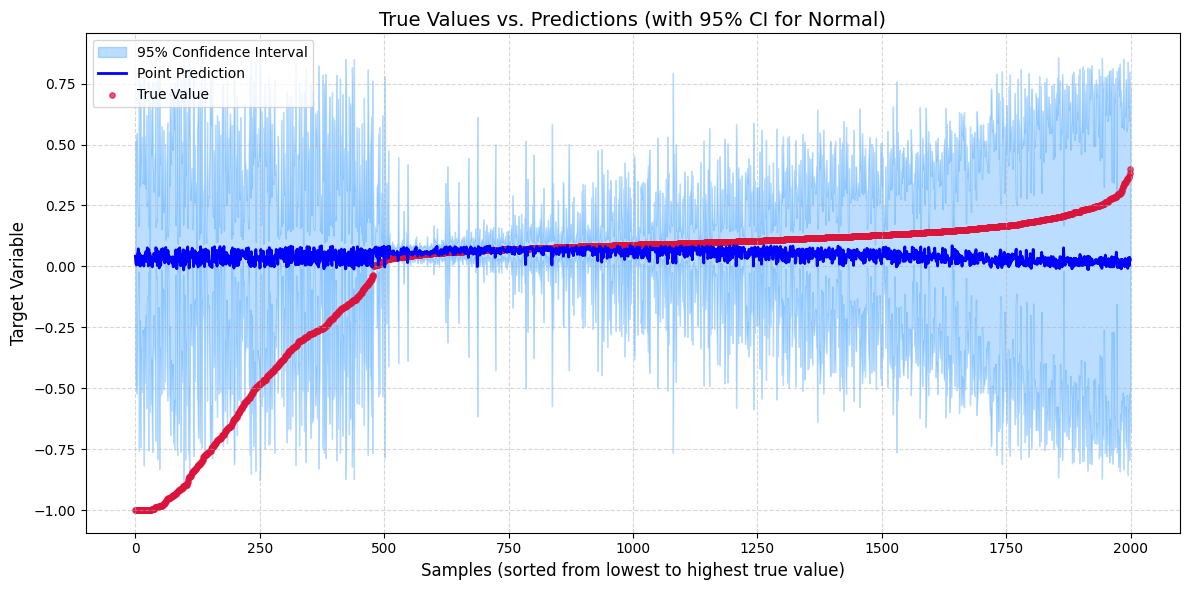

In [13]:
# Visualize the predictions with confidence intervals on the holdout set
dist_name = best_dist_str

# Calculate 95% confidence intervals based on the predicted distribution and its parameters
if dist_name == "Normal":
    lower_bound = norm.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = norm.ppf(0.975, loc=holdout_point, scale=holdout_std)
elif dist_name == "Laplace":
    lower_bound = laplace.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = laplace.ppf(0.975, loc=holdout_point, scale=holdout_std)

# Sort the holdout predictions and true values for better visualization
sort_idx = np.argsort(y_val_holdout)
y_true_sorted = y_val_holdout[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

# Plot the true values, predictions and confidence intervals
plt.figure(figsize=(12, 6))
plt.fill_between(
    range(len(y_true_sorted)),
    lower_sorted,
    upper_sorted,
    color="dodgerblue",
    alpha=0.3,
    label="95% Confidence Interval",
)
plt.plot(
    range(len(y_true_sorted)),
    y_pred_sorted,
    color="blue",
    linewidth=2,
    label="Point Prediction",
)
plt.scatter(
    range(len(y_true_sorted)),
    y_true_sorted,
    color="crimson",
    s=15,
    alpha=0.7,
    label="True Value",
)
plt.title(f"True Values vs. Predictions (with 95% CI for {dist_name})", fontsize=14)
plt.xlabel("Samples (sorted from lowest to highest true value)", fontsize=12)
plt.ylabel("Target Variable", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

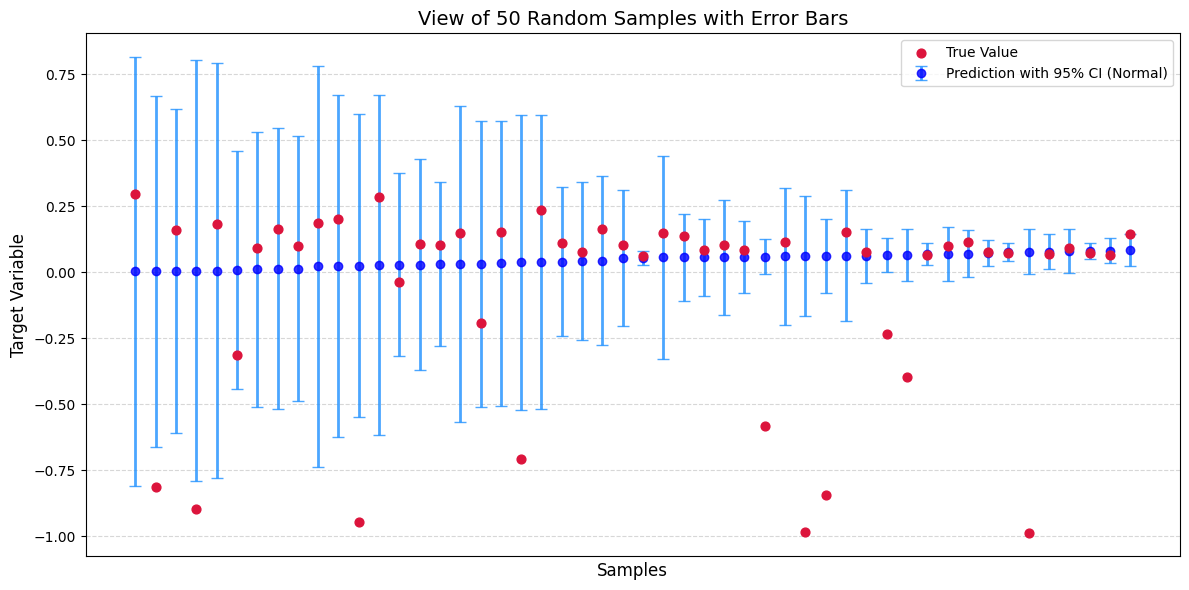

In [14]:
# Plot a subset of samples with error bars to better visualize the confidence intervals
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

# Extract the true values, predictions and confidence intervals for the sampled indices
y_true_sample = y_val_holdout[sample_idx]
y_pred_sample = holdout_point[sample_idx]
lower_sample = lower_bound[sample_idx]
upper_sample = upper_bound[sample_idx]

# Sort the sampled predictions and true values for better visualization
sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
lower_sample = lower_sample[sort_idx]
upper_sample = upper_sample[sort_idx]

# Calculate the error bars for the plot
yerr_lower = y_pred_sample - lower_sample
yerr_upper = upper_sample - y_pred_sample

# Plot the sampled predictions with error bars representing the confidence intervals
plt.figure(figsize=(12, 6))
plt.errorbar(
    range(n_samples),
    y_pred_sample,
    yerr=[yerr_lower, yerr_upper],
    fmt="o",
    color="blue",
    ecolor="dodgerblue",
    elinewidth=2,
    capsize=4,
    alpha=0.8,
    label=f"Prediction with 95% CI ({dist_name})",
)
plt.scatter(
    range(n_samples), y_true_sample, color="crimson", s=40, zorder=3, label="True Value"
)
plt.title(f"View of {n_samples} Random Samples with Error Bars", fontsize=14)
plt.xlabel("Samples", fontsize=12)
plt.ylabel("Target Variable", fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### 100k

In [ ]:
# Parameter tuning settings
timeout_seconds = 60 * 60 * 3
no_improvement_trials = 100

# Split the 100k dataset to evaluate on holdout after tuning
X_tuning = train_100k_X.head(80000)
y_tuning = train_100k_y_reg.head(80000)
X_val_holdout = train_100k_X.tail(20000)
y_val_holdout = train_100k_y_reg.tail(20000)


# Define the objective function for Optuna to optimize
def objective_ngboost(trial):
    # Possible parameters to tune with ranges
    base_params = {
        "criterion": "friedman_mse",
        "max_depth": trial.suggest_int("base_max_depth", 2, 20),  # Max tree depth
        "min_samples_split": trial.suggest_int(
            "base_min_samples_split", 10, 500
        ),  # Min samples required to split an internal node
        "min_samples_leaf": trial.suggest_int(
            "base_min_samples_leaf", 10, 500
        ),  # Min samples required in a leaf node
        "min_weight_fraction_leaf": trial.suggest_float(
            "base_min_weight_fraction_leaf", 0, 0.5
        ),  # Min weight fraction required in a leaf node
        "max_features": trial.suggest_categorical(
            "base_max_features", ["sqrt", "log2", None]
        ),  # Number of features to consider when looking for the best split
        "ccp_alpha": trial.suggest_float(
            "base_ccp_alpha", 1e-5, 0.1, log=True
        ),  # Complexity parameter for Minimal Cost-Complexity Pruning
        "max_leaf_nodes": trial.suggest_int(
            "base_max_leaf_nodes", 5, 512
        ),  # Max leaf nodes in the tree
        "min_impurity_decrease": trial.suggest_float(
            "base_min_impurity_decrease", 0, 1.0
        ),  # Min impurity decrease required for a split
        "random_state": 42,  # For reproducibility
    }

    base_learner = DecisionTreeRegressor(**base_params)

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 100, 1000
        ),  # Number of boosting rounds,
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.005, 0.2, log=True
        ),  # Step size
        "minibatch_frac": trial.suggest_float(
            "minibatch_frac", 0.5, 1.0
        ),  # Fraction of data to use for fitting each base learner
        "col_sample": trial.suggest_float(
            "col_sample", 0.3, 1.0
        ),  # Fraction of features to consider for each base learner
        "random_state": 42,  # For reproducibility
        "verbose": False,  # No verbose output during training
    }

    # Suggest distribution as a string
    dist_choice = trial.suggest_categorical("Dist", ["Normal", "Laplace"])

    # Map the string to the imported class
    dist_mapping = {"Normal": Normal, "Laplace": Laplace}
    selected_dist = dist_mapping[dist_choice]

    full_pipeline = make_pipeline(
        numeric_preprocessor_reg,
        NGBRegressor(Dist=selected_dist, Base=base_learner, Score=CRPScore, **params),
    )

    # TimeSeriesSplit to respect order of data 5 splits for 5-fold CV
    tscv = TimeSeriesSplit(n_splits=5)
    cv_scores = []

    # 5-fold CV cycle
    for train_idx, val_idx in tscv.split(X_tuning):
        X_tr, X_val = X_tuning.iloc[train_idx], X_tuning.iloc[val_idx]
        y_tr = y_tuning.iloc[train_idx].values
        y_val = y_tuning.iloc[val_idx].values

        # Suppress warnings during fitting
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                full_pipeline.fit(
                    X_tr,
                    y_tr,
                )
                # Calculate CRPS
                mean_fold_crps = full_pipeline.score(X_val, y_val) 
        except np.linalg.LinAlgError:
            return 0.0

        cv_scores.append(mean_fold_crps)

    # Return mean CRPS across folds as the metric to minimize
    return np.mean(cv_scores)


# Custom callback to stop optimization if no improvement in best CRPS for a certain number of trials
def stop_optuna(study, trial):
    if study.best_trial.number + no_improvement_trials <= trial.number:
        print(
            f"\n[Early Stop] No improvement in {no_improvement_trials} trials. Stopping optimization."
        )
        study.stop()


# Create Optuna study and optimize
study_ngboost = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
study_ngboost.optimize(
    objective_ngboost, timeout=timeout_seconds, n_jobs=-1, callbacks=[stop_optuna]
)

# Print best results and optimal parameters
print("\n" + "=" * 40)
print(f"BEST CRPS: {study_ngboost.best_value:.4f}")
print("BEST PARAMETERS:")

print("best_params = {")
for k, v in study_ngboost.best_params.items():
    if isinstance(v, str):
        print(f'    "{k}": "{v}",')
    else:
        print(f'    "{k}": {v},')
print("}")

# Calculate and print parameter importance
print("\n--- PARAMETER IMPORTANCE ---")
importances = optuna.importance.get_param_importances(study_ngboost)
for param, importance in importances.items():
    print(f"  {param:20}: {importance:.4f}")
print("=" * 40)

# Generate and show visualizations of optimization history,
# parameter importance and parallel coordinate plot
fig1 = plot_optimization_history(study_ngboost)
fig1.show()

fig2 = plot_param_importances(study_ngboost)
fig2.show()

fig3 = plot_parallel_coordinate(study_ngboost)
fig3.show()

# Save visualizations as HTML files
fig1.write_html(NGBOOST_TUNING_DIR_REG / "optuna_ngboost_crps_100k_history.html")
fig2.write_html(NGBOOST_TUNING_DIR_REG / "optuna_ngboost_crps_100k_importance.html")
fig3.write_html(NGBOOST_TUNING_DIR_REG / "optuna_ngboost_crps_100k_parallel.html")

[I 2026-05-04 22:58:34,335] A new study created in memory with name: no-name-3e93190c-810e-4fc4-bf90-463a1b6c7af0
/Users/oskarklima/Documents/Oskar/Škola/Bakalářka/Praktická část/Github/bachelor_thesis/.venv/lib/python3.10/site-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
[I 2026-05-04 23:03:03,951] Trial 7 finished with value: 0.1560933312839475 and parameters: {'base_max_depth': 12, 'base_min_samples_split': 435, 'base_min_samples_leaf': 140, 'base_min_weight_fraction_leaf': 0.21775443501327185, 'base_max_features': 'sqrt', 'base_ccp_alpha': 0.0010509950902166858, 'base_max_leaf_nodes': 390, 'base_min_impurity_decrease': 0.8751427829693974, 'n_estimators': 266, 'learning_rate': 0.06046776184835573, 'minibatch_frac': 0.5927220064545705, 'col_sample': 0.828786979344


BEST CRPS: 0.1428
BEST PARAMETERS:
best_params = {
    "base_max_depth": 6,
    "base_min_samples_split": 370,
    "base_min_samples_leaf": 55,
    "base_min_weight_fraction_leaf": 0.023063554740156644,
    "base_max_features": None,
    "base_ccp_alpha": 1.5678575150605078e-05,
    "base_max_leaf_nodes": 231,
    "base_min_impurity_decrease": 0.9254240780342731,
    "n_estimators": 775,
    "learning_rate": 0.013414300062166583,
    "minibatch_frac": 0.8153498884932472,
    "col_sample": 0.5413169982792909,
    "Dist": "Normal",
}

--- PARAMETER IMPORTANCE ---
  Dist                : 0.9320
  base_min_weight_fraction_leaf: 0.0367
  base_max_features   : 0.0090
  base_min_samples_leaf: 0.0077
  learning_rate       : 0.0036
  n_estimators        : 0.0031
  base_min_samples_split: 0.0022
  base_max_depth      : 0.0012
  base_min_impurity_decrease: 0.0011
  base_max_leaf_nodes : 0.0011
  minibatch_frac      : 0.0008
  col_sample          : 0.0008
  base_ccp_alpha      : 0.0006


In [ ]:
# Check overfit on holdout set with best parameters from tuning
best_params = study_ngboost.best_params.copy()

# Separate parametersfor base learner and extraxt the distribution choice
best_dist_str = best_params.pop("Dist")
dist_mapping = {"Normal": Normal, "Laplace": Laplace}
best_dist = dist_mapping[best_dist_str]

base_params = {
    "criterion": "friedman_mse",
    "max_depth": best_params.pop("base_max_depth"),
    "min_samples_split": best_params.pop("base_min_samples_split"),
    "min_samples_leaf": best_params.pop("base_min_samples_leaf"),
    "min_weight_fraction_leaf": best_params.pop("base_min_weight_fraction_leaf"),
    "max_features": best_params.pop("base_max_features"),
    "ccp_alpha": best_params.pop("base_ccp_alpha"),
    "max_leaf_nodes": best_params.pop("base_max_leaf_nodes"),
    "min_impurity_decrease": best_params.pop("base_min_impurity_decrease"),
    "random_state": 42,
}

base_learner = DecisionTreeRegressor(**base_params)

# Apply scaling trick
best_params["n_estimators"] = int(best_params["n_estimators"] * 10)
best_params["learning_rate"] = best_params["learning_rate"] / 10
# Add fixed parameters to best_params and print them
best_params["random_state"] = 42
best_params["verbose"] = False
print(f"BEST DIST: {best_dist_str}")
print(f"BASE PARAMS: {base_params}")
print(f"BEST PARAMS: {best_params}")

y_tuning = y_tuning.values
y_val_holdout = y_val_holdout.values

final_pipeline = make_pipeline(
    numeric_preprocessor_reg,
    NGBRegressor(Dist=best_dist, Score=CRPScore, Base=base_learner, **best_params),
)

# Fit on the entire tuning set
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    final_pipeline.fit(X_tuning, y_tuning)

# Evaluate on holdout set
X_val_transformed = final_pipeline[:-1].transform(X_val_holdout)
holdout_dist = final_pipeline.named_steps["ngbregressor"].pred_dist(X_val_transformed)
holdout_point = holdout_dist.loc
holdout_std = holdout_dist.scale
holdout_crps = final_pipeline.score(X_val_holdout, y_val_holdout)
holdout_rmse = np.sqrt(mean_squared_error(y_val_holdout, holdout_point))

# Print comparison of Optuna CV CRPS and holdout test CRPS
print("\n" + "=" * 40)
print(f"Optuna Val CRPS:   {study_ngboost.best_value:.4f}")
print(f"Holdout Test CRPS: {holdout_crps:.4f}")
print(f"Holdout Test RMSE: {holdout_rmse:.4f}")
print("=" * 40)

BEST DIST: Normal
BASE PARAMS: {'criterion': 'friedman_mse', 'max_depth': 6, 'min_samples_split': 370, 'min_samples_leaf': 55, 'min_weight_fraction_leaf': 0.023063554740156644, 'max_features': None, 'ccp_alpha': 1.5678575150605078e-05, 'max_leaf_nodes': 231, 'min_impurity_decrease': 0.9254240780342731, 'random_state': 42}
BEST PARAMS: {'n_estimators': 7750, 'learning_rate': 0.0013414300062166583, 'minibatch_frac': 0.8153498884932472, 'col_sample': 0.5413169982792909, 'random_state': 42, 'verbose': False}

Optuna Val CRPS:   0.1428
Holdout Test CRPS: 0.1409
Holdout Test RMSE: 0.3085


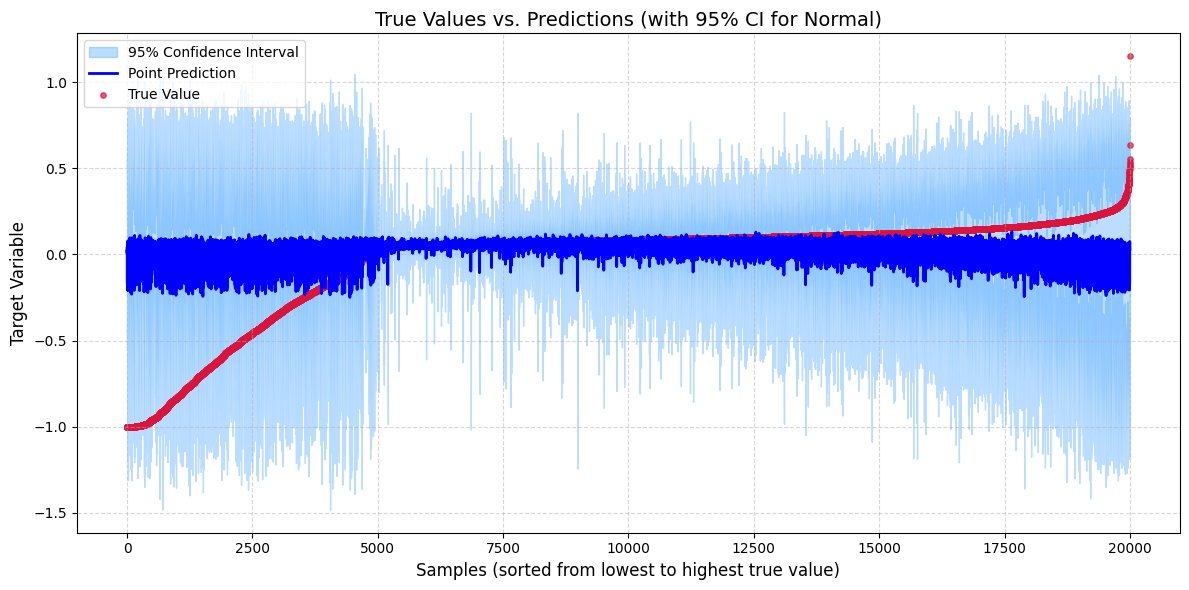

In [9]:
# Visualize the predictions with confidence intervals on the holdout set
dist_name = best_dist_str

# Calculate 95% confidence intervals based on the predicted distribution and its parameters
if dist_name == "Normal":
    lower_bound = norm.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = norm.ppf(0.975, loc=holdout_point, scale=holdout_std)
elif dist_name == "Laplace":
    lower_bound = laplace.ppf(0.025, loc=holdout_point, scale=holdout_std)
    upper_bound = laplace.ppf(0.975, loc=holdout_point, scale=holdout_std)

# Sort the holdout predictions and true values for better visualization
sort_idx = np.argsort(y_val_holdout)
y_true_sorted = y_val_holdout[sort_idx]
y_pred_sorted = holdout_point[sort_idx]
lower_sorted = lower_bound[sort_idx]
upper_sorted = upper_bound[sort_idx]

# Plot the true values, predictions and confidence intervals
plt.figure(figsize=(12, 6))
plt.fill_between(
    range(len(y_true_sorted)),
    lower_sorted,
    upper_sorted,
    color="dodgerblue",
    alpha=0.3,
    label="95% Confidence Interval",
)
plt.plot(
    range(len(y_true_sorted)),
    y_pred_sorted,
    color="blue",
    linewidth=2,
    label="Point Prediction",
)
plt.scatter(
    range(len(y_true_sorted)),
    y_true_sorted,
    color="crimson",
    s=15,
    alpha=0.7,
    label="True Value",
)
plt.title(f"True Values vs. Predictions (with 95% CI for {dist_name})", fontsize=14)
plt.xlabel("Samples (sorted from lowest to highest true value)", fontsize=12)
plt.ylabel("Target Variable", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

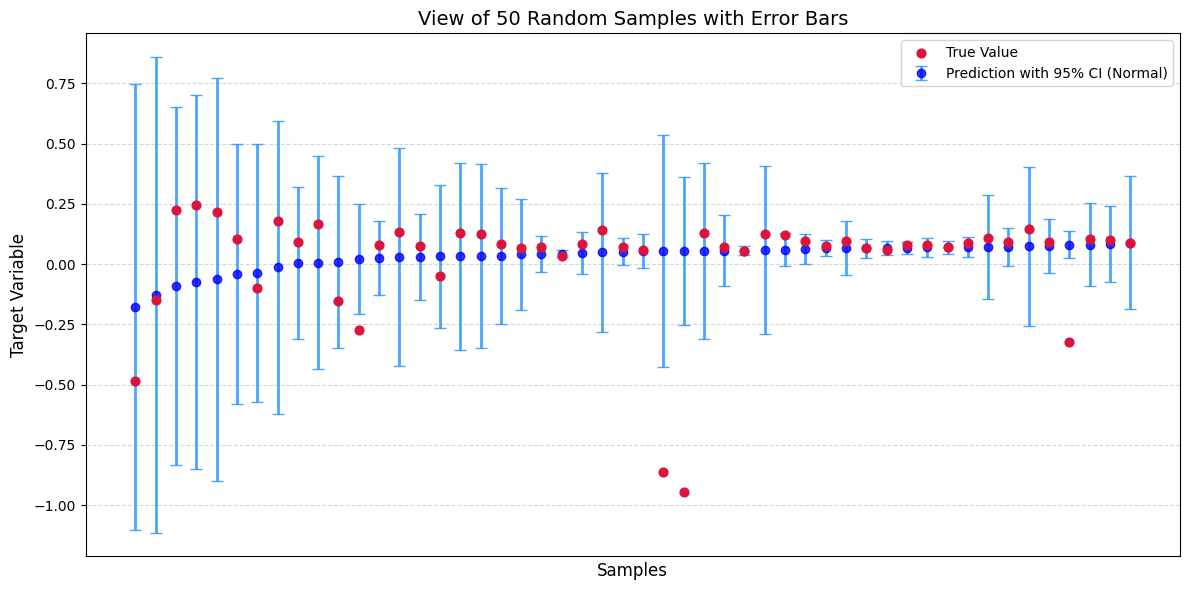

In [10]:
# Plot a subset of samples with error bars to better visualize the confidence intervals
n_samples = 50
sample_idx = np.random.choice(len(y_val_holdout), size=n_samples, replace=False)

# Extract the true values, predictions and confidence intervals for the sampled indices
y_true_sample = y_val_holdout[sample_idx]
y_pred_sample = holdout_point[sample_idx]
lower_sample = lower_bound[sample_idx]
upper_sample = upper_bound[sample_idx]

# Sort the sampled predictions and true values for better visualization
sort_idx = np.argsort(y_pred_sample)
y_true_sample = y_true_sample[sort_idx]
y_pred_sample = y_pred_sample[sort_idx]
lower_sample = lower_sample[sort_idx]
upper_sample = upper_sample[sort_idx]

# Calculate the error bars for the plot
yerr_lower = y_pred_sample - lower_sample
yerr_upper = upper_sample - y_pred_sample

# Plot the sampled predictions with error bars representing the confidence intervals
plt.figure(figsize=(12, 6))
plt.errorbar(
    range(n_samples),
    y_pred_sample,
    yerr=[yerr_lower, yerr_upper],
    fmt="o",
    color="blue",
    ecolor="dodgerblue",
    elinewidth=2,
    capsize=4,
    alpha=0.8,
    label=f"Prediction with 95% CI ({dist_name})",
)
plt.scatter(
    range(n_samples), y_true_sample, color="crimson", s=40, zorder=3, label="True Value"
)
plt.title(f"View of {n_samples} Random Samples with Error Bars", fontsize=14)
plt.xlabel("Samples", fontsize=12)
plt.ylabel("Target Variable", fontsize=12)
plt.xticks([])
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()